In [ ]:
# @title
from IPython.display import display, HTML

display(HTML("""
<div style="
  margin: 18px 0 26px 0;
  padding: 24px 26px;
  border-radius: 18px;
  background: linear-gradient(135deg, #e8f0fb 0%, #d6e4f5 45%, #c7dbf1 100%);
  border: 1px solid #b6cceb;
  box-shadow: 0 10px 24px rgba(31,119,180,0.18);
  color: #1f77b4;
">

  <div style="text-align:center;">

    <div style="
      font-size: 50px;
      font-weight: 900;
      letter-spacing: -0.6px;
      line-height: 1.1;
      margin: 0;
      color: #1f77b4;
    ">
      Projet de Machine Learning 2
    </div>

    <div style="
      margin-top: 10px;
      font-size: 30px;
      color: #1e3a5f;
      line-height: 1.4;
      font-weight: 600;
    ">
      Thème 2 — Credit scoring
      <span style="
        display:inline-block;
        margin-left: 10px;
        padding: 4px 12px;
        border-radius: 999px;
        background: #1f77b4;
        color: #ffffff;
        font-weight: 700;
        font-size:18px;
        vertical-align: middle;
      ">
        Classification
      </span>
    </div>

    <div style="
      margin-top: 16px;
      display:flex;
      justify-content:center;
      gap:10px;
    ">
      <div style="height: 6px; width: 120px; background:#1f77b4; border-radius: 999px;"></div>
      <div style="height: 6px; width: 40px; background:#4fa3d1; border-radius: 999px;"></div>
      <div style="height: 6px; width: 14px; background:#9cc7e6; border-radius: 999px;"></div>
    </div>

    <div style="
      margin-top: 16px;
      display:inline-block;
      padding: 8px 14px;
      border-radius: 14px;
      background: rgba(255,255,255,0.7);
      border: 1px solid #b6cceb;
      font-size: 13px;
      color: #0b1f3a;
      font-weight: 700;
    ">
      EDA • Prétraitement • Modélisation • Comparaison • Choix optimal
    </div>

  </div>
</div>
"""))


# ***Analyse exploratoire des données***
---

## **0. Librairies**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as msno
import warnings

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **1. Importer les données**

In [ ]:
# Importer les données
df_train = pd.read_csv('/content/drive/MyDrive/Data/application_train.csv')
POS_CASH_balance = pd.read_csv('/content/drive/MyDrive/Data/POS_CASH_balance.csv')
bureau_balance = pd.read_csv('/content/drive/MyDrive/Data/bureau_balance.csv')
df_prev = pd.read_csv('/content/drive/MyDrive/Data/previous_application.csv')
df_install = pd.read_csv('/content/drive/MyDrive/Data/installments_payments.csv')
credit_card_balance = pd.read_csv('/content/drive/MyDrive/Data/credit_card_balance.csv')
df_bureau = pd.read_csv('/content/drive/MyDrive/Data/bureau.csv')

# la base application_test ne sera pas utilisée dans notre projet

In [ ]:
df_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df_train.shape

(307511, 122)

**La Base Principale :** *application_train.csv*

C'est la base principale du projet. Elle represente l'état du client au moment où il demande son nouveau prêt.

La base contient **307 511** observations et **122** variables.

* la clé d'identification est la variable **SK_ID_CURR**
* Les variables clés sont :
  * *La Cible* : TARGET (1 = a fait défaut de paiement, 0 = a bien remboursé).
  * *Scores Externes* (Les plus importantes !) : EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3. Ce sont des scores de risque calculés par d'autres organismes.
  * *Socio-Démographie* : DAYS_BIRTH (Âge en jours négatifs), CODE_GENDER (Genre), DAYS_EMPLOYED (Ancienneté au travail), NAME_EDUCATION_TYPE (Niveau d'études).
  * *Finances* : AMT_INCOME_TOTAL (Salaire total), AMT_CREDIT (Montant du crédit demandé), AMT_ANNUITY (Mensualité prévue).
  * *Logement* : environ 40 variables décrivant l'immeuble du client (taille, ascenseur, matériaux). Elles ont beaucoup de valeurs manquantes.

In [ ]:
POS_CASH_balance.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


In [ ]:
POS_CASH_balance.shape

(10001358, 8)

**Le Suivi des Crédits Conso** : *POS_CASH_balance.csv*

Il s'agit du relevé mensuel de tous les crédits à la consommation (achat de meubles, électroménager, etc.) que le client a eus chez nous.

La base contient **10 001 358** observations et **8** variables.

* Les clés sont : **SK_ID_CURR** et **SK_ID_PREV**.
* Les variables clés :
  * *MONTHS_BALANCE* : Le mois observé.
  * *CNT_INSTALMENT_FUTURE* : Combien de mensualités lui restait-il à payer à ce moment-là ?
  * *SK_DPD* (Days Past Due) : Combien de jours de retard avait-il sur ce mois précis ?

In [ ]:
bureau_balance.head()

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


In [ ]:
bureau_balance.shape

(27299925, 3)

**Le Détail du Passé Externe** : *bureau_balance.csv*

Pour chaque vieux crédit externe, on regarde mois par mois ce qu'il s'est passé.
La base de données contient **27 299 925** observations et **3** variables.
* La clé est **SK_ID_BUREAU** (Se rattache uniquement à *bureau.csv*).
* Les variables clés sont :
    * *MONTHS_BALANCE* : Le mois en question (ex: -1 = le mois dernier, -24 = il y a deux ans).
    * *STATUS* : L'état du crédit ce mois-là ("C" = Fermé, "0" = À jour, "1" = 1 à 30 jours de retard, "2" = 31 à 60 jours de retard, etc.).

In [ ]:
df_prev.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_prev.shape

(1670214, 37)


**Le Passé Interne** : *previous_application.csv*
Ici, on regarde toutes les fois où ce client a demandé un crédit **chez nous** ("Prêt à dépenser") dans le passé.
La base de données contient **1 670 214** observations et **37** variables.
* Les clés sont **SK_ID_CURR** (ID client) et **SK_ID_PREV** (ID de l'ancienne demande de prêt).
* Les variables clés sont :
    * *NAME_CONTRACT_STATUS* : Statut de l'ancienne demande (Approuvée, Refusée, Annulée, Inutilisée).
    * *AMT_APPLICATION* : Le montant que le client avait demandé.
    * *AMT_CREDIT* : Le montant qu'on lui avait finalement accordé.
    * *CODE_REJECT_REASON* : Si on avait refusé, pourquoi ?

In [ ]:
df_install.head()

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


In [ ]:
df_install.shape

(13605401, 8)

**La Vérité du Terrain** : *installments_payments.csv*

Il présente l'historique de **chaque virement bancaire** fait pour rembourser les crédits internes.
Elle contient **13 605 401** observations et **8** variables.
* Les clés sont : **SK_ID_CURR** et **SK_ID_PREV**.
* Les variables clés sont :
    * *DAYS_INSTALMENT* : Le jour où le client **devait** payer.
    * *DAYS_ENTRY_PAYMENT* : Le jour où le client **a réellement** payé. *(La différence entre les deux donne les jours de retard !)*
    * *AMT_INSTALMENT* : Le montant exigé.
    * *AMT_PAYMENT* : Le montant versé. *(La différence donne les paiements partiels).*

In [ ]:
credit_card_balance.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


In [ ]:
credit_card_balance.shape

(3840312, 23)

**Le Suivi des Cartes Bleues** : *credit_card_balance.csv*

Si le client avait une carte de crédit renouvelable (revolving) chez nous, voici son relevé de compte mensuel.

La base de données contient **3 840 312** observations et **23** variables.

* Les clés sont : **SK_ID_CURR** et **SK_ID_PREV**.
* Les variables clés sont :
    * *AMT_BALANCE* : Le solde de la carte (ce qu'il doit).
    * *AMT_CREDIT_LIMIT_ACTUAL* : Le plafond de sa carte de crédit.
    * *AMT_DRAWINGS_ATM_CURRENT* : Le montant qu'il a retiré en espèces à un distributeur automatique ce mois-là.
    * *AMT_PAYMENT_CURRENT* : Combien il a remboursé sur sa carte ce mois-là.

In [ ]:
df_bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [ ]:
df_bureau.shape

(1716428, 17)

**Le Passé Externe** : *bureau.csv*

Cette table liste tous les anciens crédits que le client a pris **dans d'autres banques** (déclarés au bureau des crédits).

La base contient **1 716 428** observations et **17** variables.

* Les clés sont : **SK_ID_CURR** (ID client) et **SK_ID_BUREAU** (ID de ce crédit externe spécifique).
* Les variables clés sont :
    * *CREDIT_ACTIVE* : Est-ce que ce crédit est "Fermé" (remboursé) ou "Actif" (encore en cours) ?
    * *DAYS_CREDIT* : Il y a combien de jours ce crédit a-t-il été ouvert ?
    * *AMT_CREDIT_SUM* : Quel était le montant total de ce crédit ?
    * *AMT_CREDIT_SUM_DEBT* : Combien le client doit-il encore rembourser sur ce crédit aujourd'hui ?

### Rapport HTML généré automatiquement

In [ ]:
# from ydata_profiling import ProfileReport

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')

# Configuration Pandas pour tout voir
pd.set_option('display.max_columns', 150)
pd.set_option('display.max_rows', 150)

## **2. Traitement de la base principale et de la table historique**

Il s'agit des tables `application_train` et `previous_application`.

In [ ]:
print(f"Dimensions de application_train : {df_train.shape}")
print(f"Dimensions de previous_application : {df_prev.shape}")

Dimensions de application_train : (307511, 122)
Dimensions de previous_application : (1670214, 37)


### 2.1 Statistiques descriptives de la table df_train

In [ ]:
display(df_train.describe(include="all").T.head(15))


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,NaN,NaN,NaN,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,NaN,NaN,NaN,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
NAME_CONTRACT_TYPE,307511,2,Cash loans,278232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE_GENDER,307511,3,F,202448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_CAR,307511,2,N,202924,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_REALTY,307511,2,Y,213312,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CNT_CHILDREN,307511.0,NaN,NaN,NaN,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,NaN,NaN,NaN,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,NaN,NaN,NaN,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307499.0,NaN,NaN,NaN,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5


Ces statistiques descriptives permettent de faire plusieurs constats :

* **Déséquilibre de la variable cible (TARGET) :** Seulement **8,07 %** des prêts de la base sont en défaut de paiement.

* **Profil Socio-Démographique dominant :** On remarque que le demandeur "type" de l'échantillon est une femme (~66 %), mariée, exerçant une activité professionnelle, propriétaire de son bien immobilier et sollicitant un crédit en espèces (Cash loan) de manière non accompagnée.

### 2.2 Valeurs manquantes

<Figure size 1500x500 with 0 Axes>

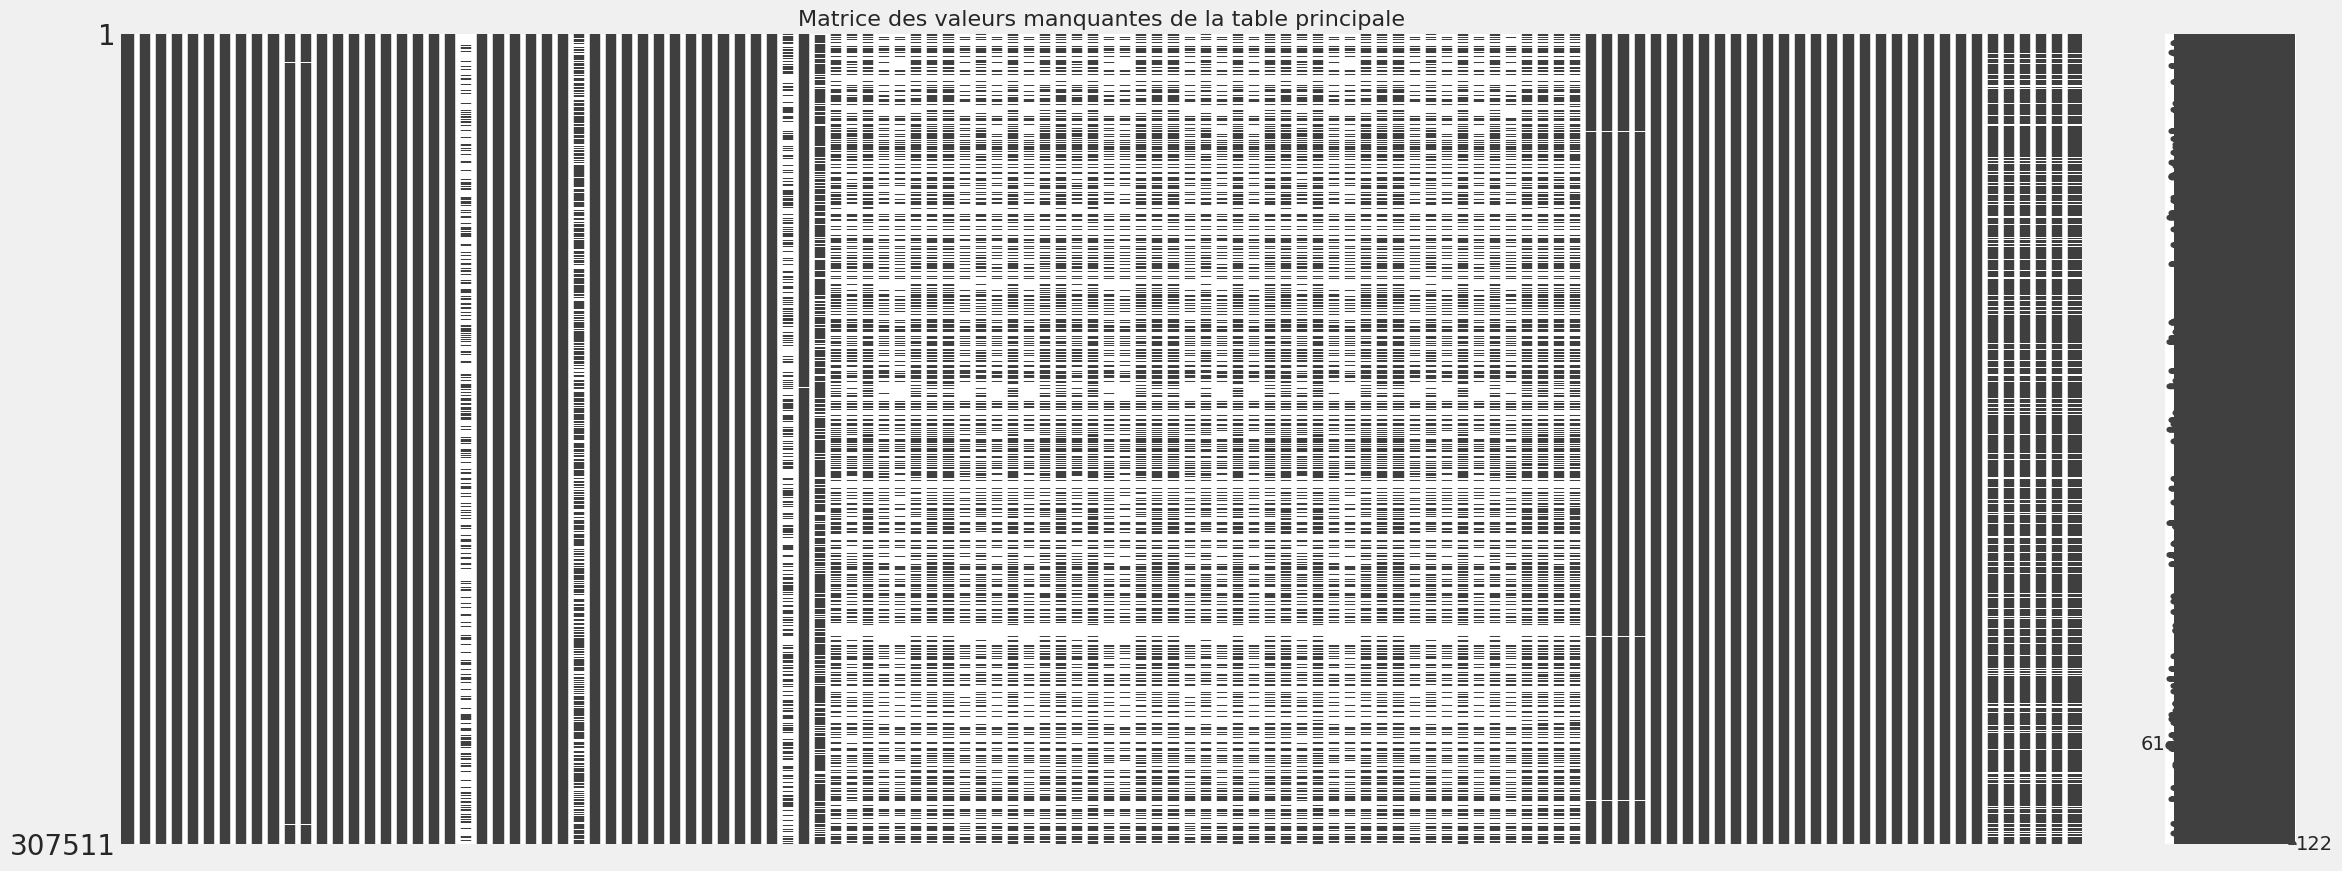

<Figure size 1500x500 with 0 Axes>

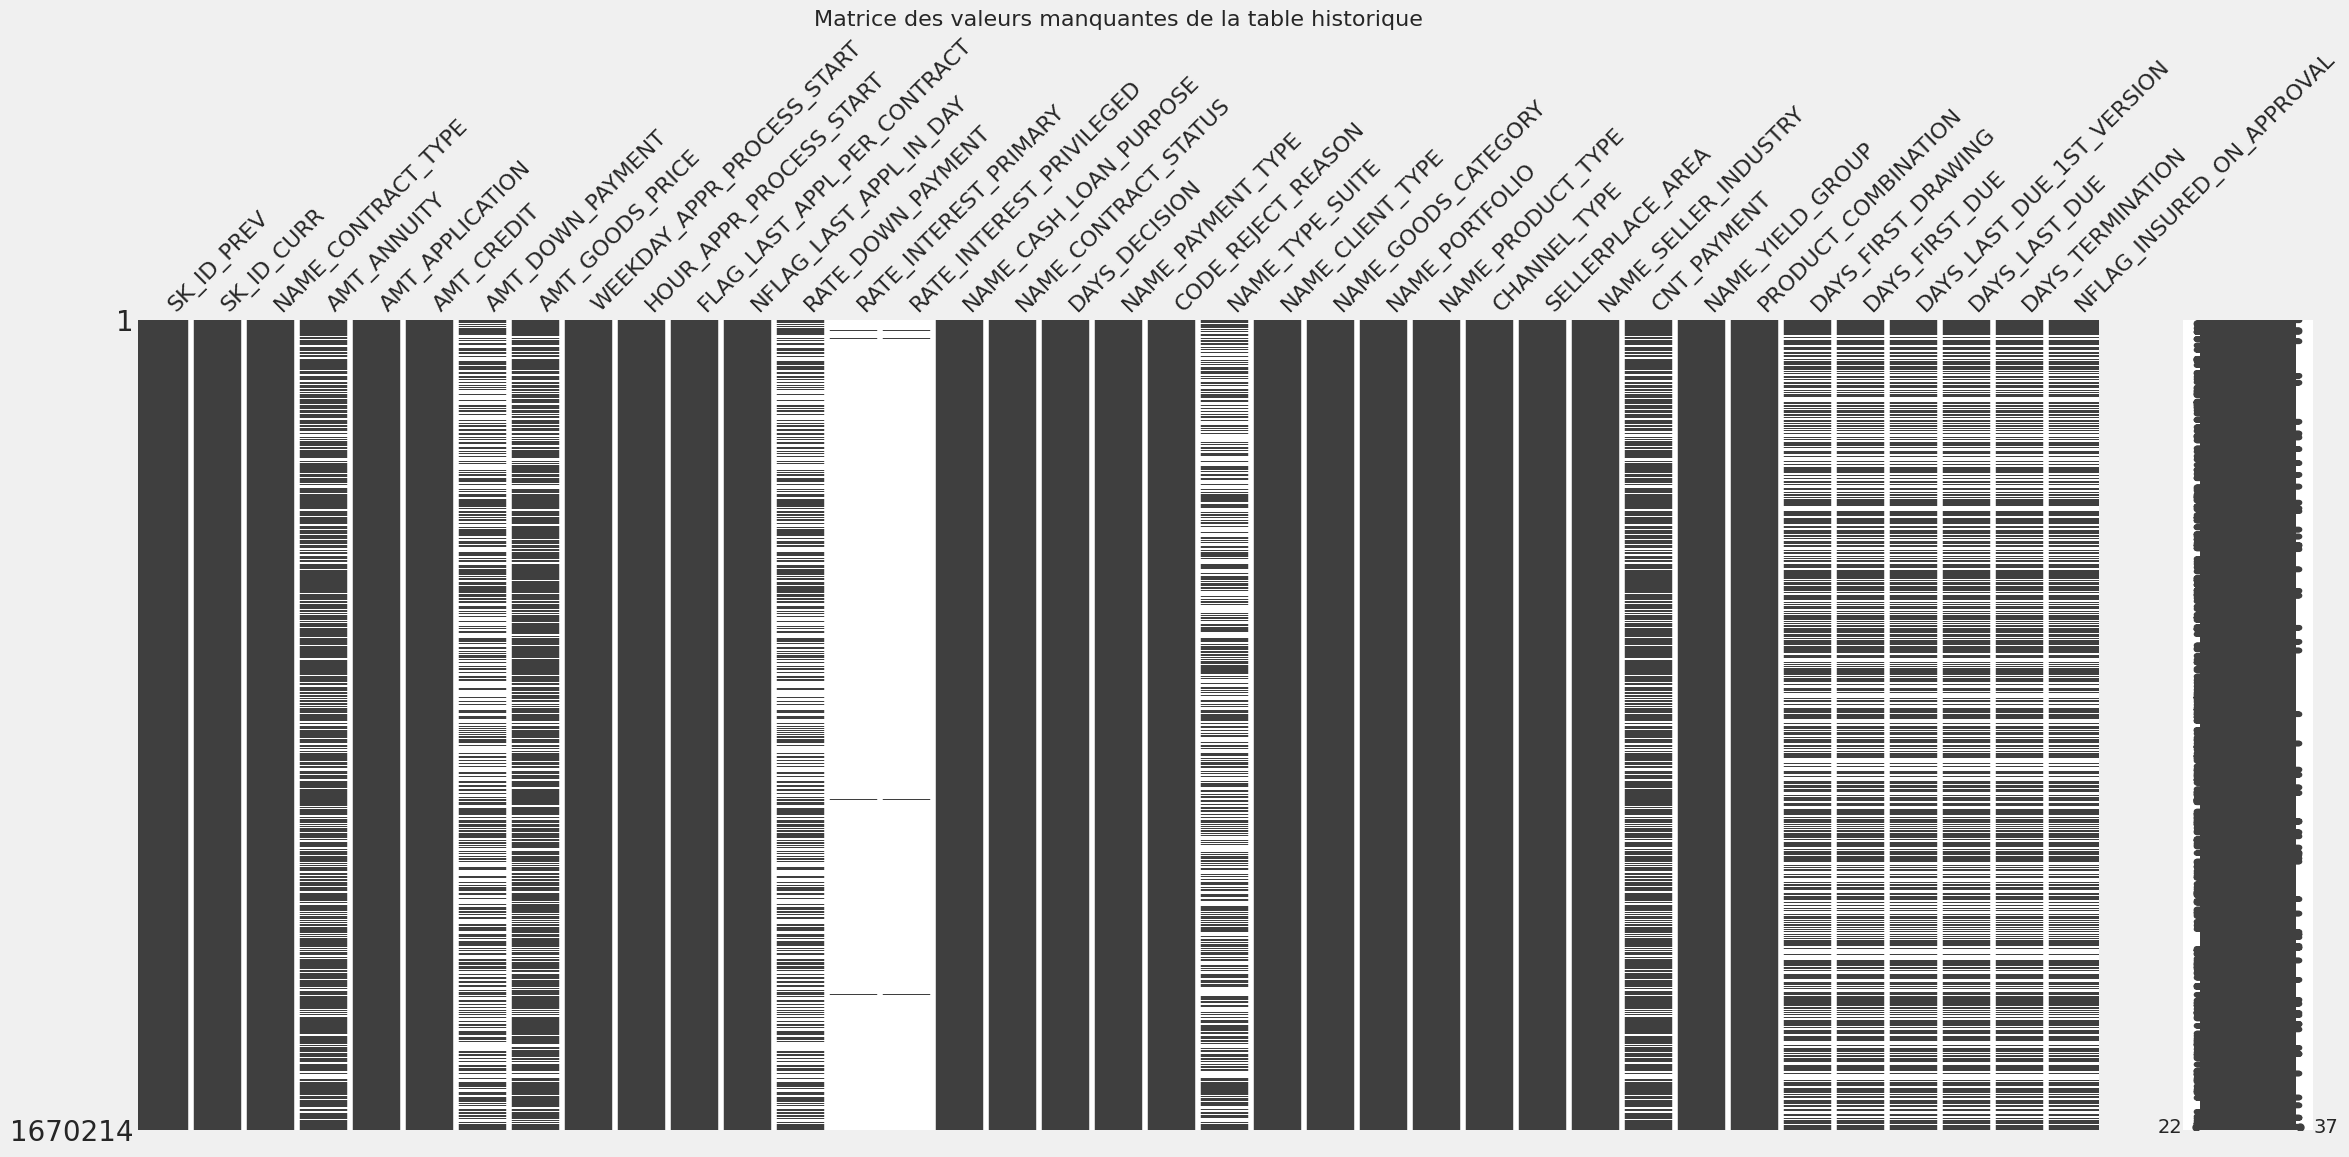

In [ ]:
# Visualisation des valeurs manquantes
plt.figure(figsize=(15, 5))
msno.matrix(df_train)
plt.title("Matrice des valeurs manquantes de la table principale", fontsize=16)
plt.show()

# Visualisation des valeurs manquantes
plt.figure(figsize=(15, 5))
msno.matrix(df_prev)
plt.title("Matrice des valeurs manquantes de la table historique", fontsize=16)
plt.show()



On note que chacune des deux tables a beaucoup de valeurs manquantes. Certaines variables pour lesquelles ces valeurs manquantes du fait de leur fort taux ne peuvent pas être imputées seront supprimées.

In [ ]:
# Traitement des valeurs manquantes

# 1. Fonction pour afficher les 20 colonnes ayant le plus de valeurs manquantes
def check_missing_data(df, title):
    total = df.isnull().sum().sort_values(ascending=False)
    percent = (df.isnull().sum() / df.isnull().count() * 100).sort_values(ascending=False)
    missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
    print(f"\n Top 20 des colonnes ayant le plus de valeurs manquantes : {title}")
    display(missing_data.head(20))
    return missing_data

# Affichage pour df_train
missing_train = check_missing_data(df_train, "Table Train (application_train)")


 Top 20 des colonnes ayant le plus de valeurs manquantes : Table Train (application_train)


,Total,Percent
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


In [ ]:
# Affichage pour df_prev
missing_prev = check_missing_data(df_prev, "Table Previous (previous_application)")


 Top 20 des colonnes ayant le plus de valeurs manquantes : Table Previous (previous_application)


,Total,Percent
RATE_INTEREST_PRIVILEGED,1664263,99.643698
RATE_INTEREST_PRIMARY,1664263,99.643698
AMT_DOWN_PAYMENT,895844,53.636480
RATE_DOWN_PAYMENT,895844,53.636480
NAME_TYPE_SUITE,820405,49.119754
DAYS_TERMINATION,673065,40.298129
DAYS_FIRST_DRAWING,673065,40.298129
DAYS_FIRST_DUE,673065,40.298129
DAYS_LAST_DUE_1ST_VERSION,673065,40.298129
DAYS_LAST_DUE,673065,40.298129


In [ ]:
# Identification des colonnes à supprimer (> 50% de NaN)
cols_to_drop_train = missing_train[missing_train['Percent'] > 50].index.tolist()
protected_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
cols_to_drop_prev = missing_prev[missing_prev['Percent'] > 50].index.tolist()

print(f"\nNombre de colonnes à supprimer dans df_train (>50% NaN) : {len(cols_to_drop_train)}")
print(f"Nombre de colonnes à supprimer dans df_prev (>50% NaN) : {len(cols_to_drop_prev)}")

# Suppression
cols_to_drop_train = [col for col in cols_to_drop_train if col not in protected_cols]
df_train.drop(columns=cols_to_drop_train, inplace=True)
df_prev.drop(columns=cols_to_drop_prev, inplace=True)



Nombre de colonnes à supprimer dans df_train (>50% NaN) : 41
Nombre de colonnes à supprimer dans df_prev (>50% NaN) : 4


Les variables présentant plus de 50 % de données manquantes ont été identifiées comme peu informatives et ont été supprimées afin d’améliorer la qualité et la fiabilité du jeu de données. Toutefois, certaines variables jugées pertinentes pour la modélisation (notamment `EXT_SOURCE_1`, `EXT_SOURCE_2` et `EXT_SOURCE_3`) ont été conservées malgré leur taux élevé de valeurs manquantes. En effet, ces variables correspondent à des scores de risque normalisés provenant d'institutions de crédit externes. Statistiquement, ce sont les *features* les plus fortement corrélées avec la variable cible.

In [ ]:
print("\n--- Nouvel état des bases après nettoyage : ---")
print(f"Dimensions finales df_train : {df_train.shape}")
print(f"Dimensions finales df_prev : {df_prev.shape}")


--- Nouvel état des bases après nettoyage : ---
Dimensions finales df_train : (307511, 82)
Dimensions finales df_prev : (1670214, 33)


La table principale a désormais 82 variables, et celle historique en a désormais 33.

## **3. Analyse de la Variable Cible (TARGET)**

In [ ]:
# Distribution de la variable cible
target_counts = df_train['TARGET'].value_counts(normalize=True) * 100

fig = px.pie(
    values=target_counts.values,
    names=['Payé à temps (0)', 'Défaut de paiement (1)'],
    title='Distribution de la variable cible (TARGET)',
    color_discrete_sequence=['#2ecc71', '#e74c3c'],
    hole=0.4
)
fig.show()

L'observation de la distribution de la variable cible met en évidence un **déséquilibre de classes (class imbalance) majeur** : la classe 0 (Prêt remboursé) : Représente la vaste majorité des cas (environ 92 %) tandis que la classe 1 (Défaut de paiement) : ne représente qu'une infime minorité des cas (environ 8 %).

Ce fort déséquilibre nous indique qu'un algorithme classique pourrait obtenir 92 % de bonnes prédictions (*Accuracy*) simplement en prédisant que tout le monde va rembourser, ce qui rendrait le modèle inutile pour la banque.

## **4. Analyse bivariée**

### *4.1 Analyse Financière*

Il s'agit de croiser les variables **AMT_INCOME_TOTAL** (revenus), **AMT_CREDIT** (montant de crédit) et **AMT_GOODS_PRICE** (prix des biens) avec la variable cible TARGET.

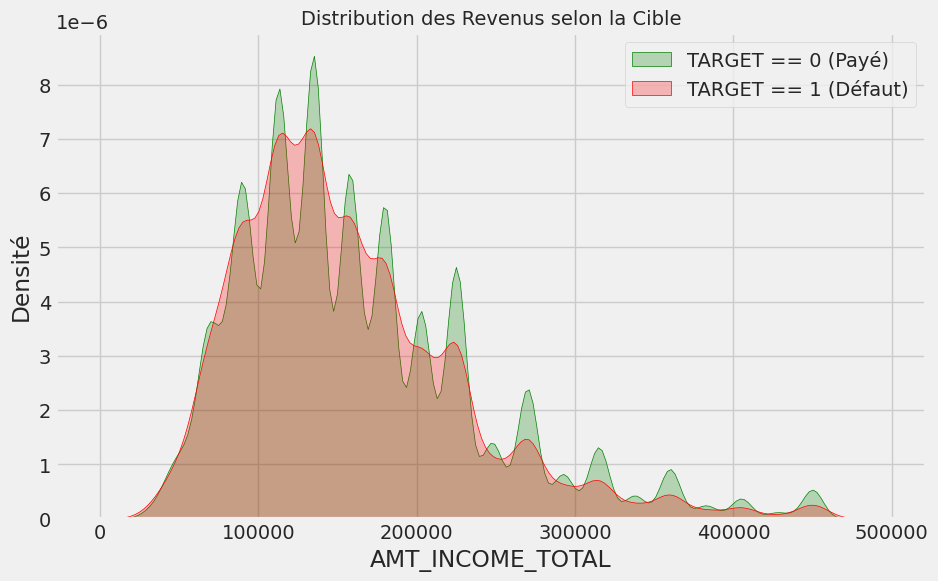

In [ ]:
# Fonction réutilisable pour afficher la distribution selon la TARGET
def plot_distribution_by_target(df, feature, title):
    plt.figure(figsize=(10, 6))
    sns.kdeplot(df.loc[df['TARGET'] == 0, feature], label='TARGET == 0 (Payé)', color='g', shade=True)
    sns.kdeplot(df.loc[df['TARGET'] == 1, feature], label='TARGET == 1 (Défaut)', color='r', shade=True)
    plt.title(title, fontsize=14)
    plt.xlabel(feature)
    plt.ylabel('Densité')
    plt.legend()
    plt.show()

# Distribution des revenus (Attention aux outliers extrêmes, on filtre au 99e percentile pour la visu)
income_cap = df_train['AMT_INCOME_TOTAL'].quantile(0.99)
df_train_filtered = df_train[df_train['AMT_INCOME_TOTAL'] < income_cap]

plot_distribution_by_target(df_train_filtered, 'AMT_INCOME_TOTAL', 'Distribution des Revenus selon la Cible')

La distribution des **revenus** est très similaire entre les clients en défaut et ceux qui remboursent, ce qui montre que le revenu seul ne permet pas de bien discriminer le risque de défaut. Une légère tendance indique que les individus à revenus plus faibles sont un peu plus exposés au défaut de paiement, mais cette relation reste faible.

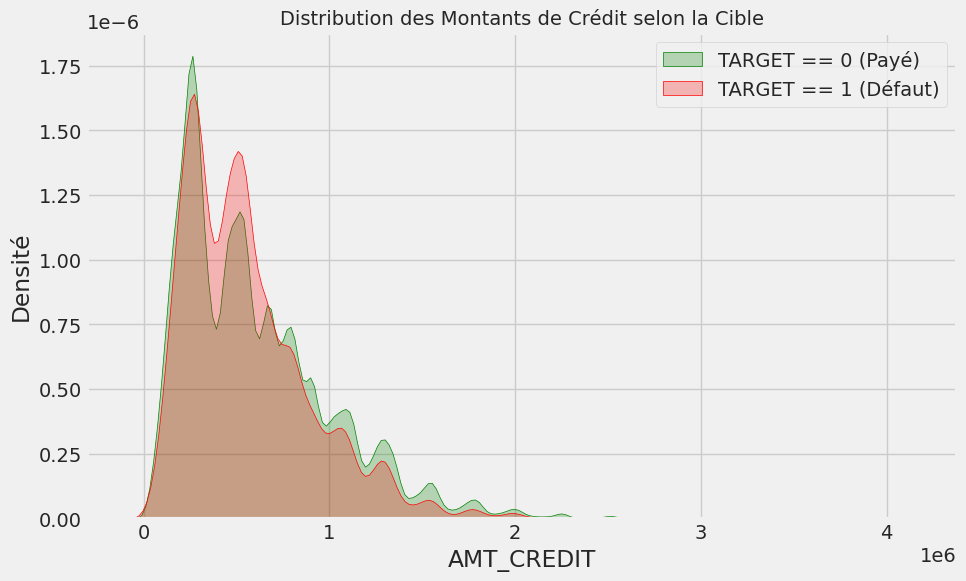

In [ ]:
plot_distribution_by_target(df_train, 'AMT_CREDIT', 'Distribution des Montants de Crédit selon la Cible')

Le **montant du crédit** présente une légère capacité discriminante : les crédits de faible montant sont davantage associés à des remboursements, tandis que les crédits intermédiaires semblent légèrement plus risqués. Toutefois, le fort chevauchement entre les distributions montre que cette variable reste insuffisante pour prédire seule le défaut.

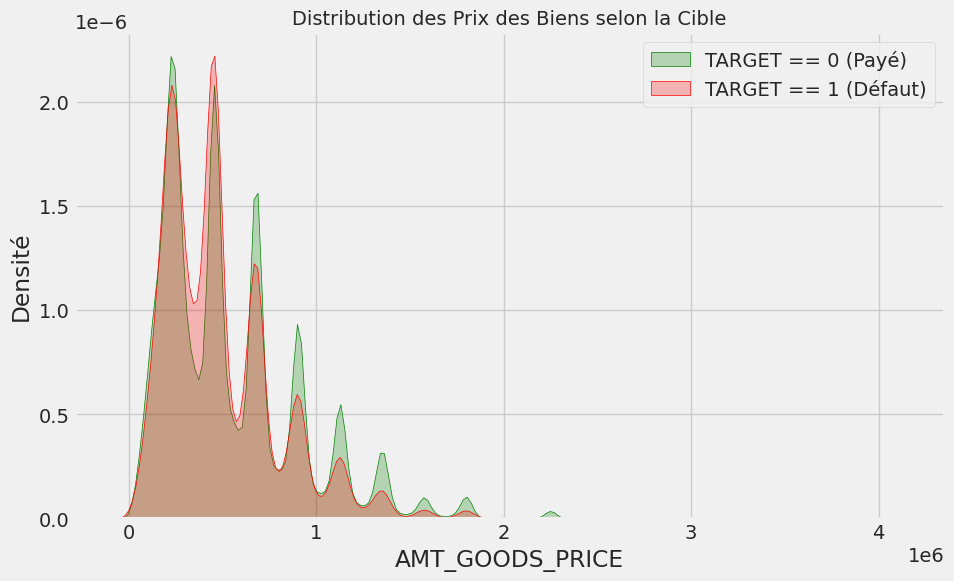

In [ ]:
plot_distribution_by_target(df_train, 'AMT_GOODS_PRICE', 'Distribution des Prix des Biens selon la Cible')

Le **prix des biens** présente une distribution très similaire entre les clients en défaut et ceux qui remboursent, avec un fort chevauchement. La présence de pics suggère une standardisation des montants financés. Cette variable apporte peu d’information discriminante seule et est fortement corrélée au montant du crédit, ce qui limite son intérêt isolé dans la prédiction du défaut.

### *4.2 Analyse Financière Avancée*

Les précédentes variables fincières (revenus, montant de crédit et prix des biens) n'ont pas suffisament discrimé la variable cible. Il s'agit donc de créer des indicateurs métiers classiques du monde bancaire pour voir s'ils séparent mieux nos classes. Ces indicateurs sont :
* **Taux d'endettement (Annuity Income Ratio) :** Le pourcentage du salaire dédié au remboursement de ce prêt.
* **Ratio Prêt/Revenu (Credit Income Ratio) :** Le montant du prêt par rapport au salaire annuel.
* **Ratio Prêt/Valeur (Credit Goods Ratio) :** Le client emprunte-t-il plus que le prix du bien ?

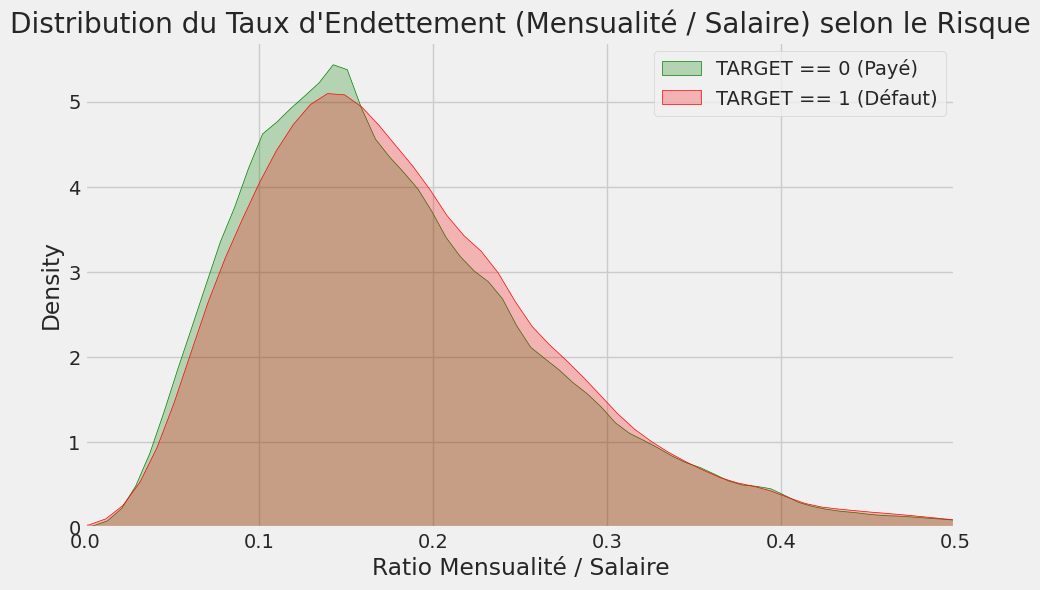

In [ ]:
# Création des nouvelles features
df_train['CREDIT_INCOME_RATIO'] = df_train['AMT_CREDIT'] / df_train['AMT_INCOME_TOTAL']
df_train['ANNUITY_INCOME_RATIO'] = df_train['AMT_ANNUITY'] / df_train['AMT_INCOME_TOTAL']
df_train['CREDIT_GOODS_RATIO'] = df_train['AMT_CREDIT'] / df_train['AMT_GOODS_PRICE']

# Visualisation du Taux d'endettement (Annuity Income Ratio)
plt.figure(figsize=(10, 6))
# On limite l'axe X pour éviter l'effet des valeurs extrêmes (outliers)
sns.kdeplot(df_train.loc[df_train['TARGET'] == 0, 'ANNUITY_INCOME_RATIO'], label='TARGET == 0 (Payé)', color='g', shade=True)
sns.kdeplot(df_train.loc[df_train['TARGET'] == 1, 'ANNUITY_INCOME_RATIO'], label='TARGET == 1 (Défaut)', color='r', shade=True)
plt.xlim(0, 0.5) # Généralement l'endettement dépasse rarement 50%
plt.title("Distribution du Taux d'Endettement (Mensualité / Salaire) selon le Risque")
plt.xlabel("Ratio Mensualité / Salaire")
plt.legend()
plt.show()

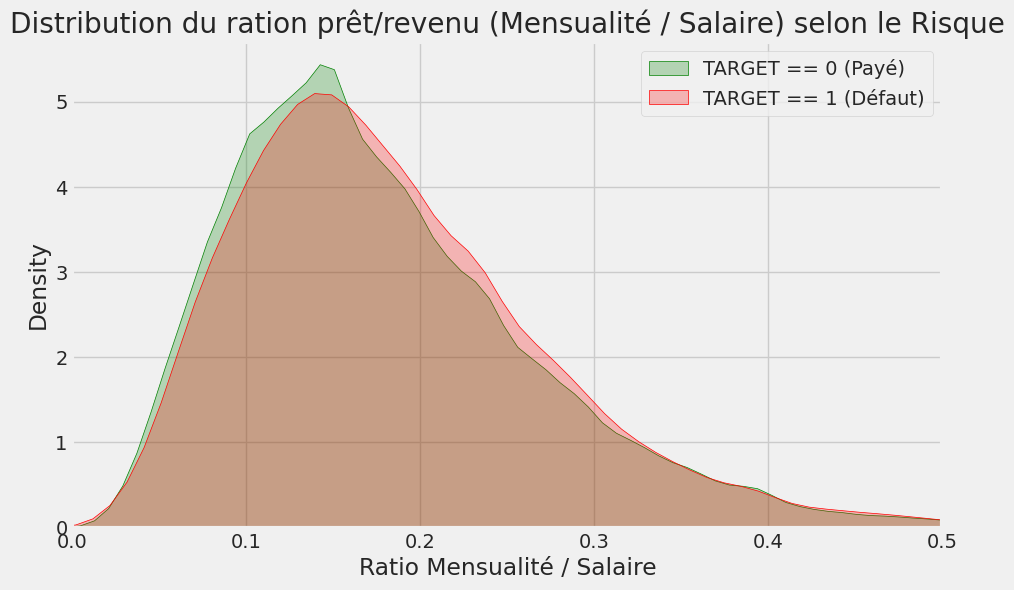

In [ ]:
df_train['ANNUITY_INCOME_RATIO'] = df_train['AMT_ANNUITY'] / df_train['AMT_INCOME_TOTAL']
df_train['CREDIT_GOODS_RATIO'] = df_train['AMT_CREDIT'] / df_train['AMT_GOODS_PRICE']

# Visualisation du Taux d'endettement (Annuity Income Ratio)
plt.figure(figsize=(10, 6))
# On limite l'axe X pour éviter l'effet des valeurs extrêmes (outliers)
sns.kdeplot(df_train.loc[df_train['TARGET'] == 0, 'ANNUITY_INCOME_RATIO'], label='TARGET == 0 (Payé)', color='g', shade=True)
sns.kdeplot(df_train.loc[df_train['TARGET'] == 1, 'ANNUITY_INCOME_RATIO'], label='TARGET == 1 (Défaut)', color='r', shade=True)
plt.xlim(0, 0.5) # Généralement l'endettement dépasse rarement 50%
plt.title("Distribution du ration prêt/revenu (Mensualité / Salaire) selon le Risque")
plt.xlabel("Ratio Mensualité / Salaire")
plt.legend()
plt.show()

Ratio Prêt/Revenu (Credit Income Ratio) : Le montant du prêt par rapport au salaire annuel.
Ratio Prêt/Valeur

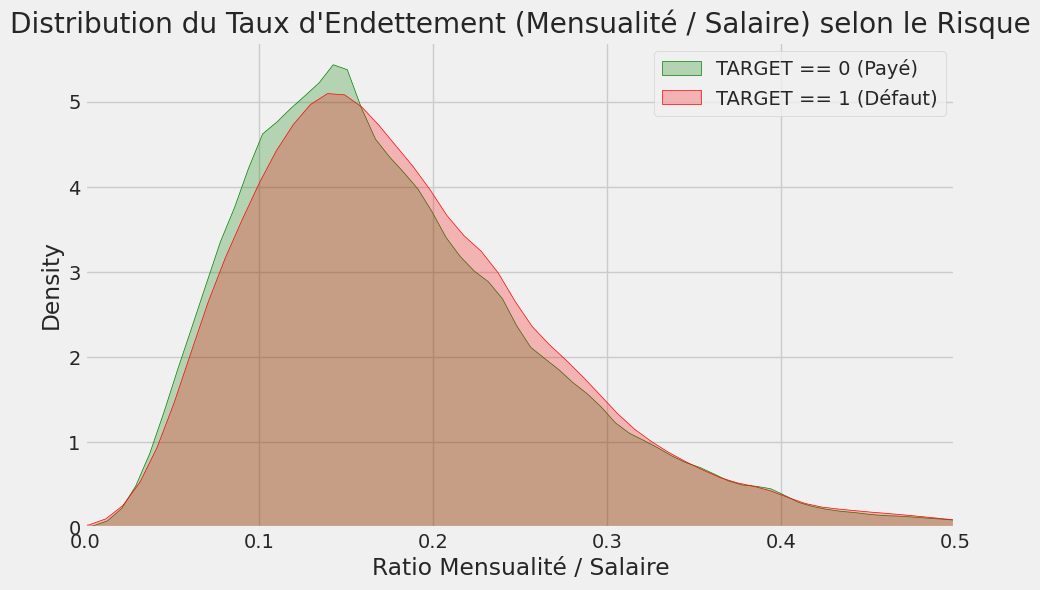

In [ ]:
df_train['ANNUITY_INCOME_RATIO'] = df_train['AMT_ANNUITY'] / df_train['AMT_INCOME_TOTAL']
df_train['CREDIT_GOODS_RATIO'] = df_train['AMT_CREDIT'] / df_train['AMT_GOODS_PRICE']

# Visualisation du Taux d'endettement (Annuity Income Ratio)
plt.figure(figsize=(10, 6))
# On limite l'axe X pour éviter l'effet des valeurs extrêmes (outliers)
sns.kdeplot(df_train.loc[df_train['TARGET'] == 0, 'ANNUITY_INCOME_RATIO'], label='TARGET == 0 (Payé)', color='g', shade=True)
sns.kdeplot(df_train.loc[df_train['TARGET'] == 1, 'ANNUITY_INCOME_RATIO'], label='TARGET == 1 (Défaut)', color='r', shade=True)
plt.xlim(0, 0.5) # Généralement l'endettement dépasse rarement 50%
plt.title("Distribution du Taux d'Endettement (Mensualité / Salaire) selon le Risque")
plt.xlabel("Ratio Mensualité / Salaire")
plt.legend()
plt.show()

# ppppprrrrrrrooooobbbbbllllèèèèèmmm

### *4.3 Analyse du profil socio-démographique*

Cette partie permettra de repondre à la question qui sont les clients qui font le plus défaut ?

Un prétraitement sera préalablement fait pour corriger l'artefact classique de cette base de données (`DAYS_EMPLOYED` = 365243) et les nombres négatifs des variables temporelles.

#### Transformation des variables temporelles

In [ ]:
print(f"Maximum de DAYS_EMPLOYED : {df_train['DAYS_EMPLOYED'].max()}")
print(f"Minimum de DAYS_EMPLOYED : {df_train['DAYS_EMPLOYED'].min()}")

Maximum de DAYS_EMPLOYED : 365243
Minimum de DAYS_EMPLOYED : -17912


In [ ]:
# Gestion de la valeur aberrante (1000 ans) dans la variable d'emploi
df_train['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

# Conversion de toutes les variables temporelles en Années Positives
df_train['AGE_YEARS'] = df_train['DAYS_BIRTH'] / -365
df_train['YEARS_EMPLOYED'] = df_train['DAYS_EMPLOYED'] / -365
df_train['YEARS_REGISTRATION'] = df_train['DAYS_REGISTRATION'] / -365
df_train['YEARS_ID_PUBLISH'] = df_train['DAYS_ID_PUBLISH'] / -365

L'artefact `365243` (qui code les non-employés/retraités) a été remplacé par des valeurs manquantes (`NaN`) pour ne pas fausser nos moyennes.
Et les jours négatifs ont été convertis en années positives pour rendre l'EDA et l'interprétabilité du modèle plus intuitives.

In [ ]:
# Statistiques descriptives des variables temporelles modifées
print("--- Statistiques des nouvelles variables temporelles (en années) ---")
display(df_train[['AGE_YEARS', 'YEARS_EMPLOYED', 'YEARS_REGISTRATION', 'YEARS_ID_PUBLISH']].describe())

--- Statistiques des nouvelles variables temporelles (en années) ---


,AGE_YEARS,YEARS_EMPLOYED,YEARS_REGISTRATION,YEARS_ID_PUBLISH
count,307511.000000,252137.000000,307511.000000,307511.000000
mean,43.936973,6.531971,13.660604,8.203294
std,11.956133,6.406466,9.651743,4.135481
min,20.517808,-0.000000,-0.000000,-0.000000
25%,34.008219,2.101370,5.506849,4.712329
50%,43.150685,4.515068,12.339726,8.915068
75%,53.923288,8.698630,20.491781,11.778082
max,69.120548,49.073973,67.594521,19.717808


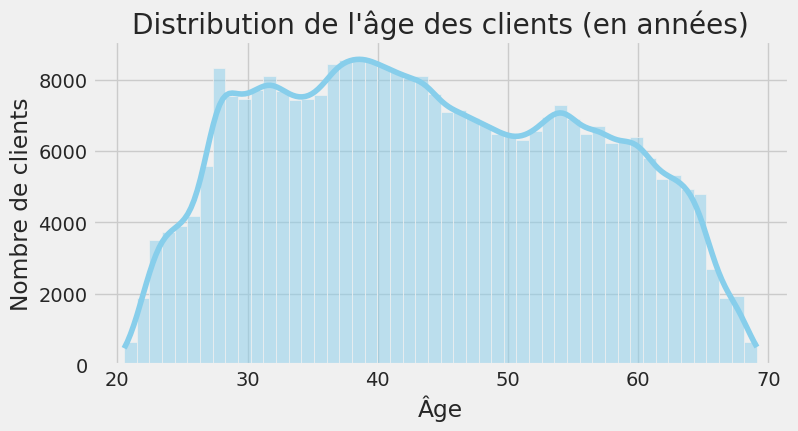

In [ ]:
# Histogramme de l'âge
plt.figure(figsize=(8, 4))
sns.histplot(df_train['AGE_YEARS'], bins=50, kde=True, color='skyblue')
plt.title("Distribution de l'âge des clients (en années)")
plt.xlabel("Âge")
plt.ylabel("Nombre de clients")
plt.show()

#### Analyse

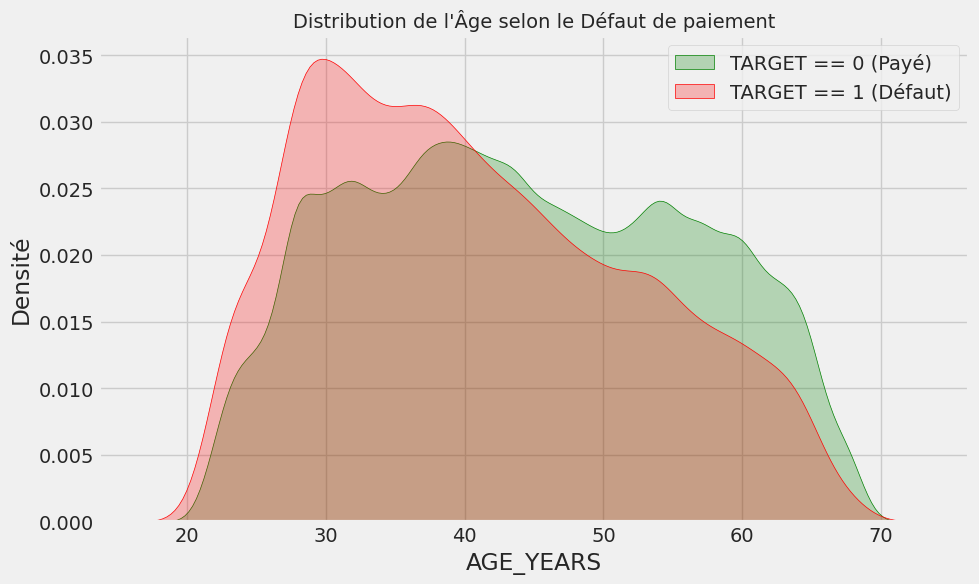

In [ ]:
# Affichage de la relation Âge vs TARGET
plot_distribution_by_target(df_train, 'AGE_YEARS', 'Distribution de l\'Âge selon le Défaut de paiement')

L’analyse de la distribution de l’**âge** selon la variable cible montre un chevauchement important entre les individus en défaut de paiement et ceux qui remboursent. Toutefois, on observe que les individus en défaut sont légèrement plus concentrés dans les tranches d’âge jeunes, notamment autour de 25 à 35 ans, tandis que les individus sans défaut sont davantage représentés aux âges plus élevés. Cela suggère que l’âge possède un certain pouvoir discriminant vis-à-vis du défaut de paiement, mais celui-ci reste limité. Ainsi, l’âge ne constitue pas à lui seul une variable suffisante pour prédire le défaut, et doit être combiné avec d’autres variables explicatives.


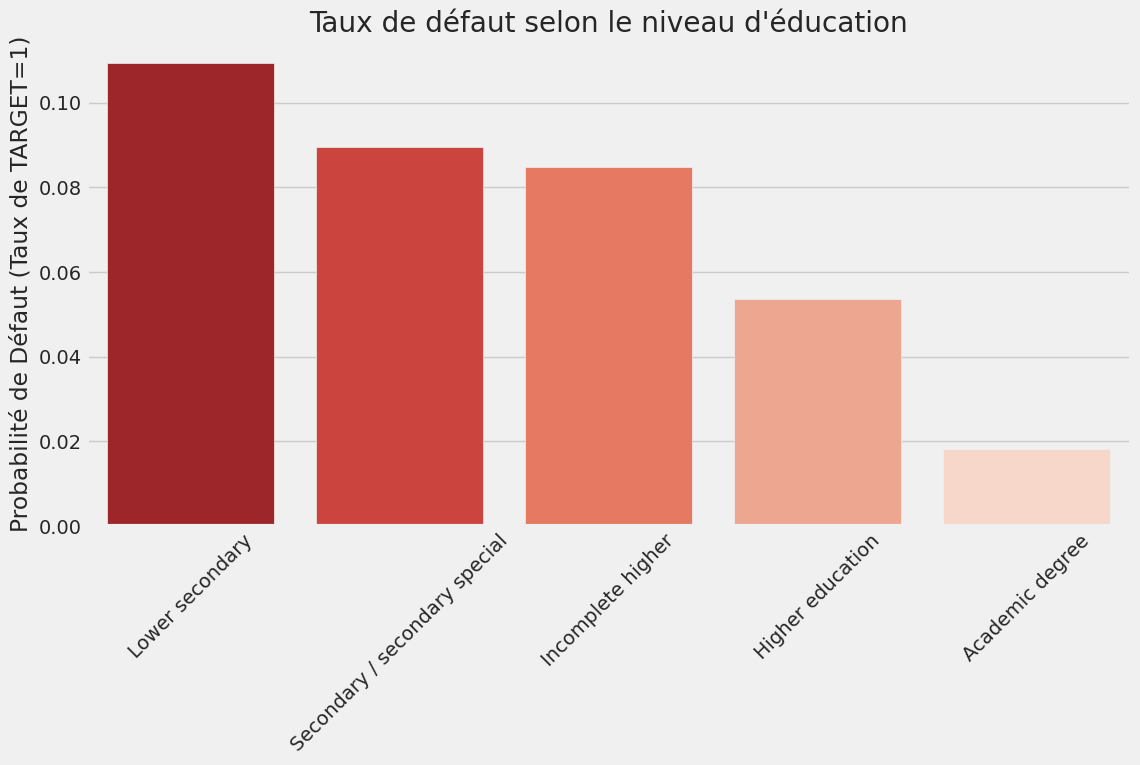

In [ ]:
# Fonction pour analyser les variables catégorielles avec le taux de défaut
def plot_categorical_bivariate(df, feature, title, rotation=45):
    # Calcul du taux de défaut par catégorie
    order_cat = df.groupby(feature)['TARGET'].mean().sort_values(ascending=False).index

    plt.figure(figsize=(12, 6))
    sns.barplot(x=feature, y='TARGET', data=df, order=order_cat, palette='Reds_r', ci=None)
    plt.xticks(rotation=rotation)
    plt.title(title)
    plt.ylabel('Probabilité de Défaut (Taux de TARGET=1)')
    plt.xlabel('')
    plt.show()

plot_categorical_bivariate(df_train, 'NAME_EDUCATION_TYPE', 'Taux de défaut selon le niveau d\'éducation')

L’analyse du taux de défaut selon le **niveau d’éducation** met en évidence une relation claire entre ces deux variables. On observe que le taux de défaut est plus élevé chez les individus ayant un faible niveau d’éducation (notamment “Lower secondary”), puis diminue progressivement à mesure que le niveau d’éducation augmente, pour atteindre son minimum chez les individus ayant un diplôme académique. Cette tendance suggère que le niveau d’éducation possède un pouvoir discriminant assez important vis-à-vis de la variable cible.


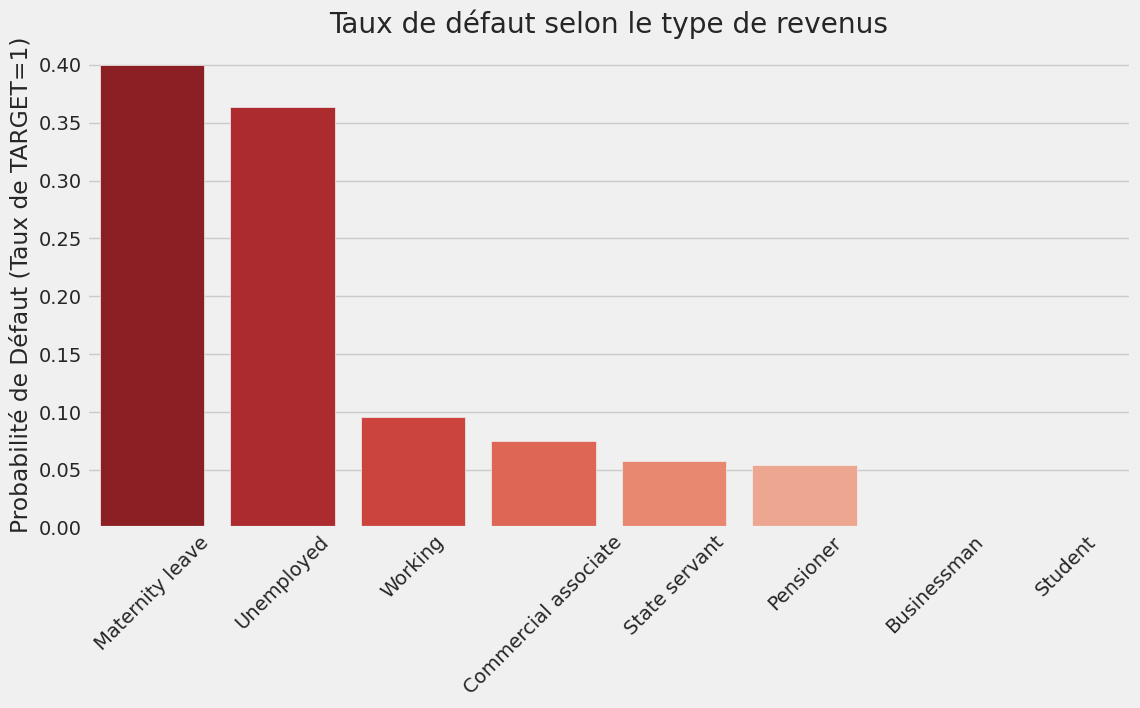

In [ ]:
plot_categorical_bivariate(df_train, 'NAME_INCOME_TYPE', 'Taux de défaut selon le type de revenus')

L’analyse du taux de défaut selon le **type de revenus** met en évidence des différences marquées entre les catégories. Les individus en congé maternité et les chômeurs présentent les taux de défaut les plus élevés. À l’inverse, les individus disposant de revenus plus stables, tels que les salariés, fonctionnaires, retraités ou commerçants, affichent des taux de défaut nettement plus faibles. Cette variabilité entre les catégories indique que le type de revenus discrimine assez bien lui aussi la variable cible.

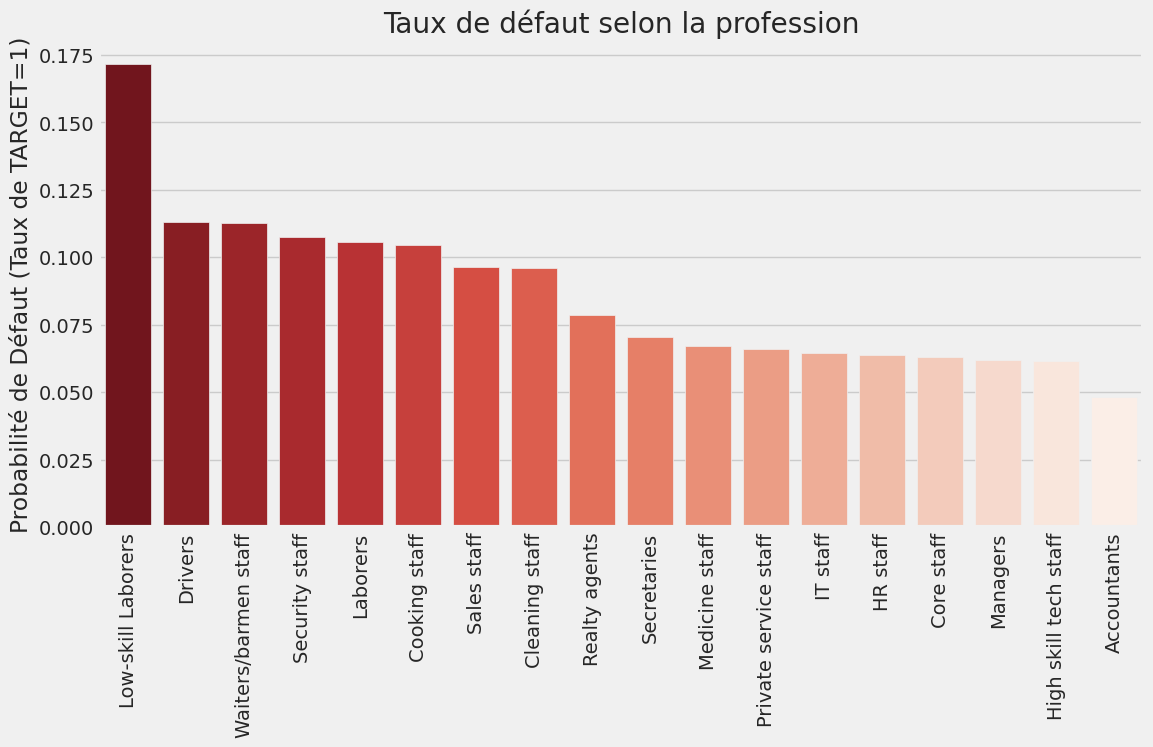

In [ ]:
plot_categorical_bivariate(df_train, 'OCCUPATION_TYPE', 'Taux de défaut selon la profession', rotation=90)

L’analyse du taux de défaut selon la **profession** présente met en évidence un pouvoir discriminant assez important vis-à-vis de la variale cible. Les métiers peu qualifiés (notamment les *low-skill laborers*) affichent les taux de défaut les plus élevés, tandis que les professions qualifiées (comptables, IT, managers) présentent des taux plus faibles.

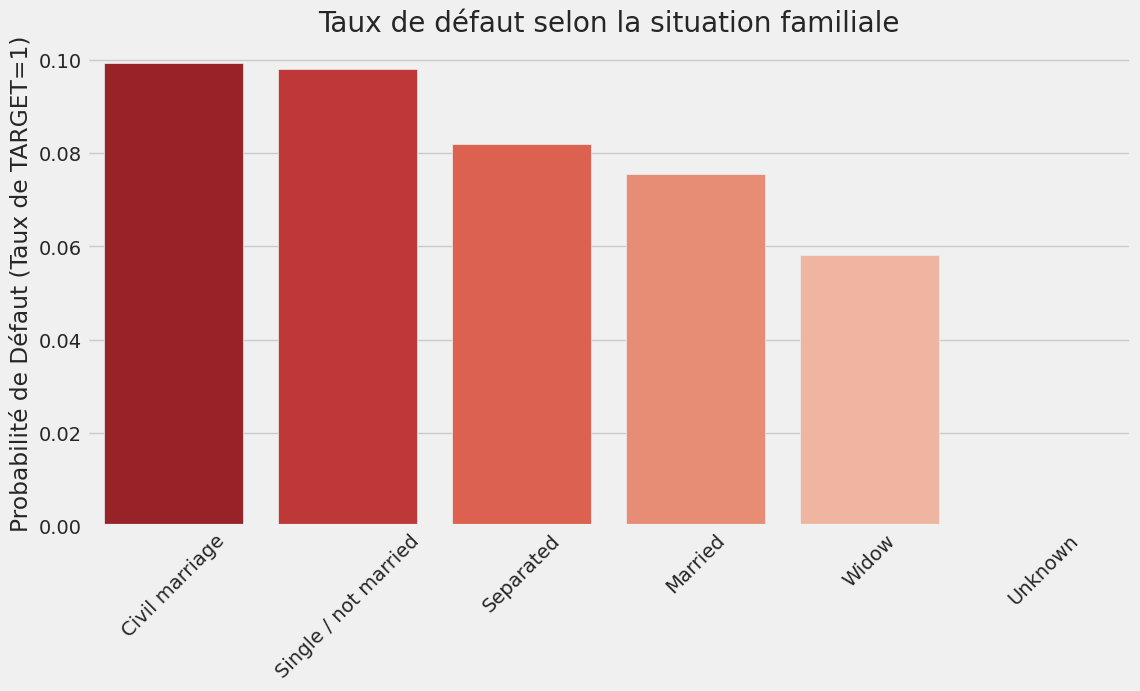

In [ ]:
plot_categorical_bivariate(df_train, 'NAME_FAMILY_STATUS', 'Taux de défaut selon la situation familiale')

L’analyse du taux de défaut selon **la situation familiale** montre une certaine capacité discriminante : les individus en union libre ou célibataires présentent les taux de défaut les plus élevés, tandis que les personnes mariées ou veuves ont des taux plus faibles.

### *4.4 Analyse des sources externes*

Les variables `EXT_SOURCE` représentent des scores de crédit provenant d'institutions tierces. Des diagrammes en violon seront utilisés pour visualiser simultanément la distribution et les quartiles en fonction de la variable cible.

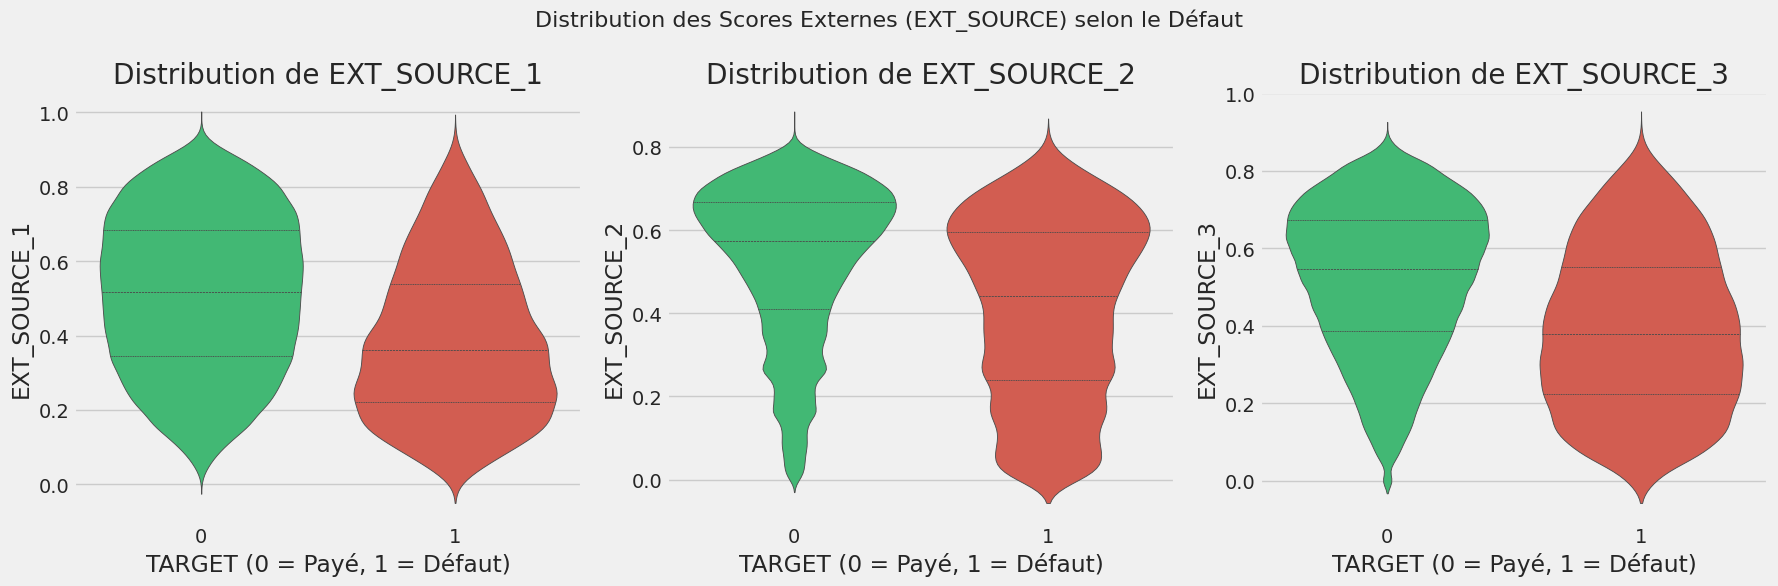

In [ ]:
# Sélection des variables
ext_data = df_train[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']]

# Création d'une figure avec 3 sous-graphiques (subplots)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plt.suptitle('Distribution des Scores Externes (EXT_SOURCE) selon le Défaut', fontsize=16)

for i, source in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    sns.violinplot(x='TARGET', y=source, data=ext_data, ax=axes[i], palette=['#2ecc71', '#e74c3c'], inner='quartile')
    axes[i].set_title(f'Distribution de {source}')
    axes[i].set_xlabel('TARGET (0 = Payé, 1 = Défaut)')

plt.tight_layout()
plt.show()

### 4.5 Analyse de l'historique des clients

## 5. Exploration de l'Historique Interne (`previous_application.csv`)
Au lieu de simplement compter les types de prêts, nous analysons les raisons des refus passés et les méthodes de paiement pour comprendre le profil de risque.

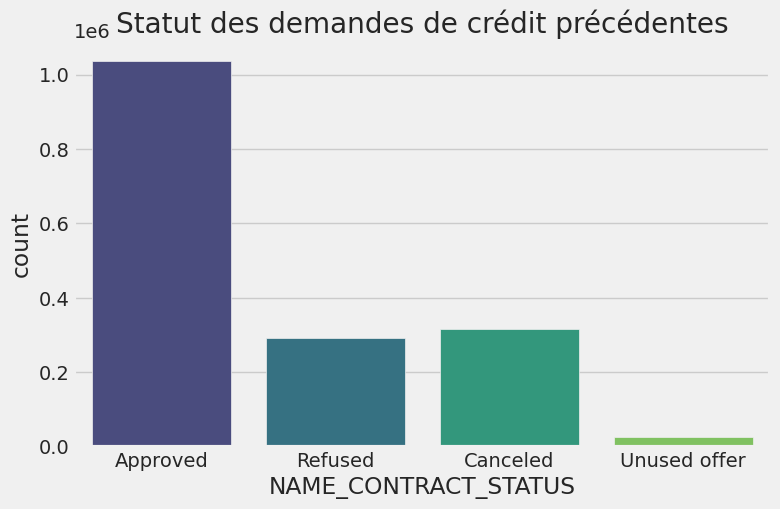

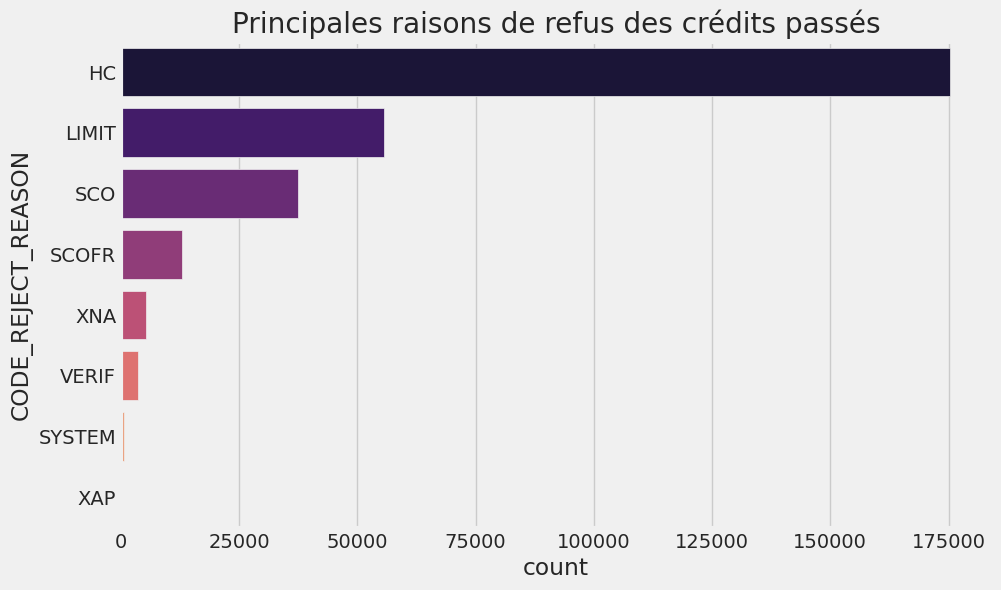

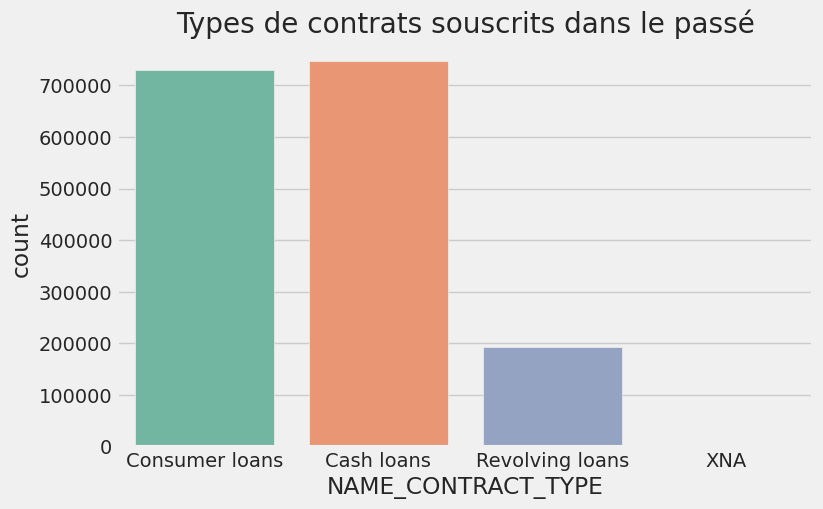

In [ ]:
# Taux d'acceptation/refus historique
plt.figure(figsize=(8, 5))
sns.countplot(x='NAME_CONTRACT_STATUS', data=df_prev, palette='viridis')
plt.title("Statut des demandes de crédit précédentes")
plt.show()

# Raisons des rejets (en filtrant les refus)
rejected_df = df_prev[df_prev['NAME_CONTRACT_STATUS'] == 'Refused']
plt.figure(figsize=(10, 6))
sns.countplot(y='CODE_REJECT_REASON', data=rejected_df, order=rejected_df['CODE_REJECT_REASON'].value_counts().index, palette='magma')
plt.title("Principales raisons de refus des crédits passés")
plt.show()

# Focus sur les types de contrats passés
plt.figure(figsize=(8, 5))
sns.countplot(x='NAME_CONTRACT_TYPE', data=df_prev, palette='Set2')
plt.title("Types de contrats souscrits dans le passé")
plt.show()

## 5.5 Exploration du Passé Externe (`bureau.csv`)
Nos clients ont-ils des dettes actives dans d'autres établissements bancaires ? Cette information est cruciale pour évaluer leur solvabilité réelle. Nous chargeons la table `bureau.csv` pour analyser le statut de ces anciens crédits.

Dimensions de bureau.csv : (1716428, 17)


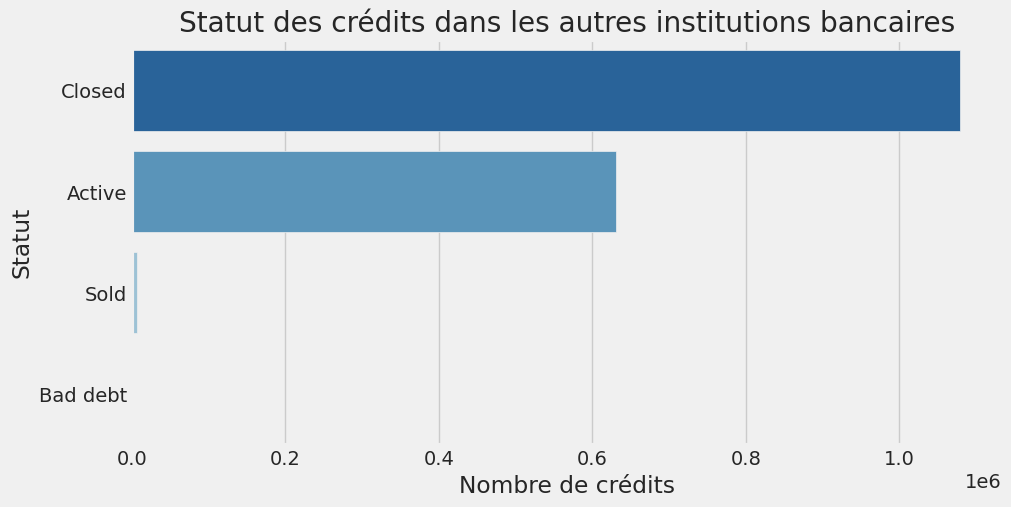

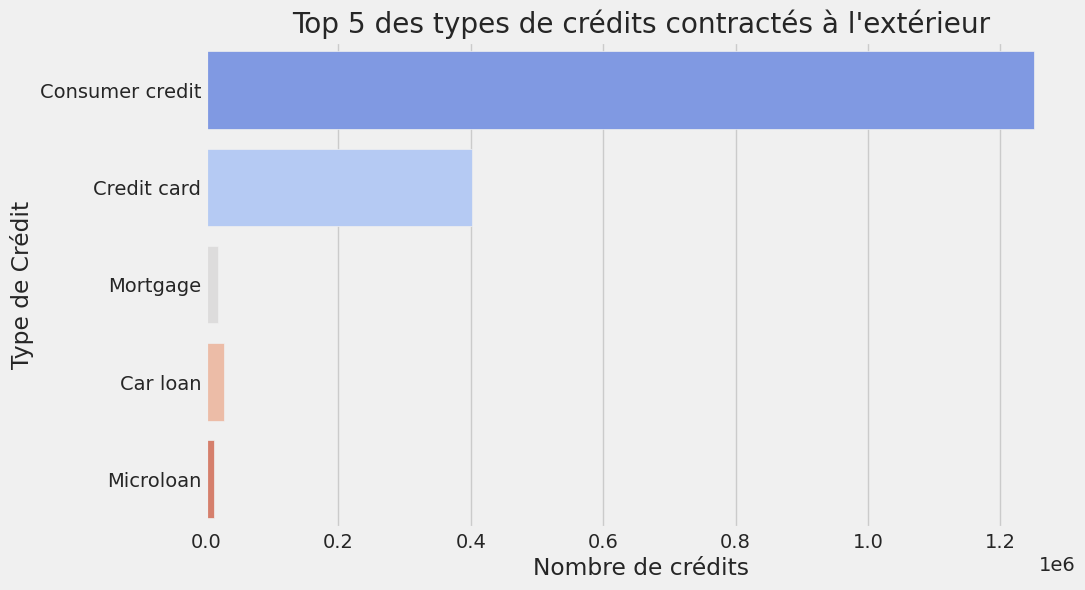

In [ ]:
# Chargement de la table (si ce n'est pas déjà fait au début)

print(f"Dimensions de bureau.csv : {df_bureau.shape}")

# Visualisation 1 : Statut des crédits externes (Actif, Fermé, Vendu...)
plt.figure(figsize=(10, 5))
sns.countplot(y='CREDIT_ACTIVE', data=df_bureau, order=df_bureau['CREDIT_ACTIVE'].value_counts().index, palette='Blues_r')
plt.title("Statut des crédits dans les autres institutions bancaires")
plt.xlabel("Nombre de crédits")
plt.ylabel("Statut")
plt.show()

# Visualisation 2 : Type de crédit (Consommation, Carte de crédit, Immobilier...)
plt.figure(figsize=(10, 6))
top_credit_types = df_bureau['CREDIT_TYPE'].value_counts().head(5).index
sns.countplot(y='CREDIT_TYPE', data=df_bureau[df_bureau['CREDIT_TYPE'].isin(top_credit_types)], palette='coolwarm')
plt.title("Top 5 des types de crédits contractés à l'extérieur")
plt.xlabel("Nombre de crédits")
plt.ylabel("Type de Crédit")
plt.show()

Analyse multivariée

## 6. Analyse Multivariée : Matrice de Corrélation
L'objectif est d'identifier les variables les plus linéairement corrélées avec la variable TARGET. Les variables `EXT_SOURCE` sont généralement les plus prédictives. On cherche également la multicolinéarité (comme vu en cours).

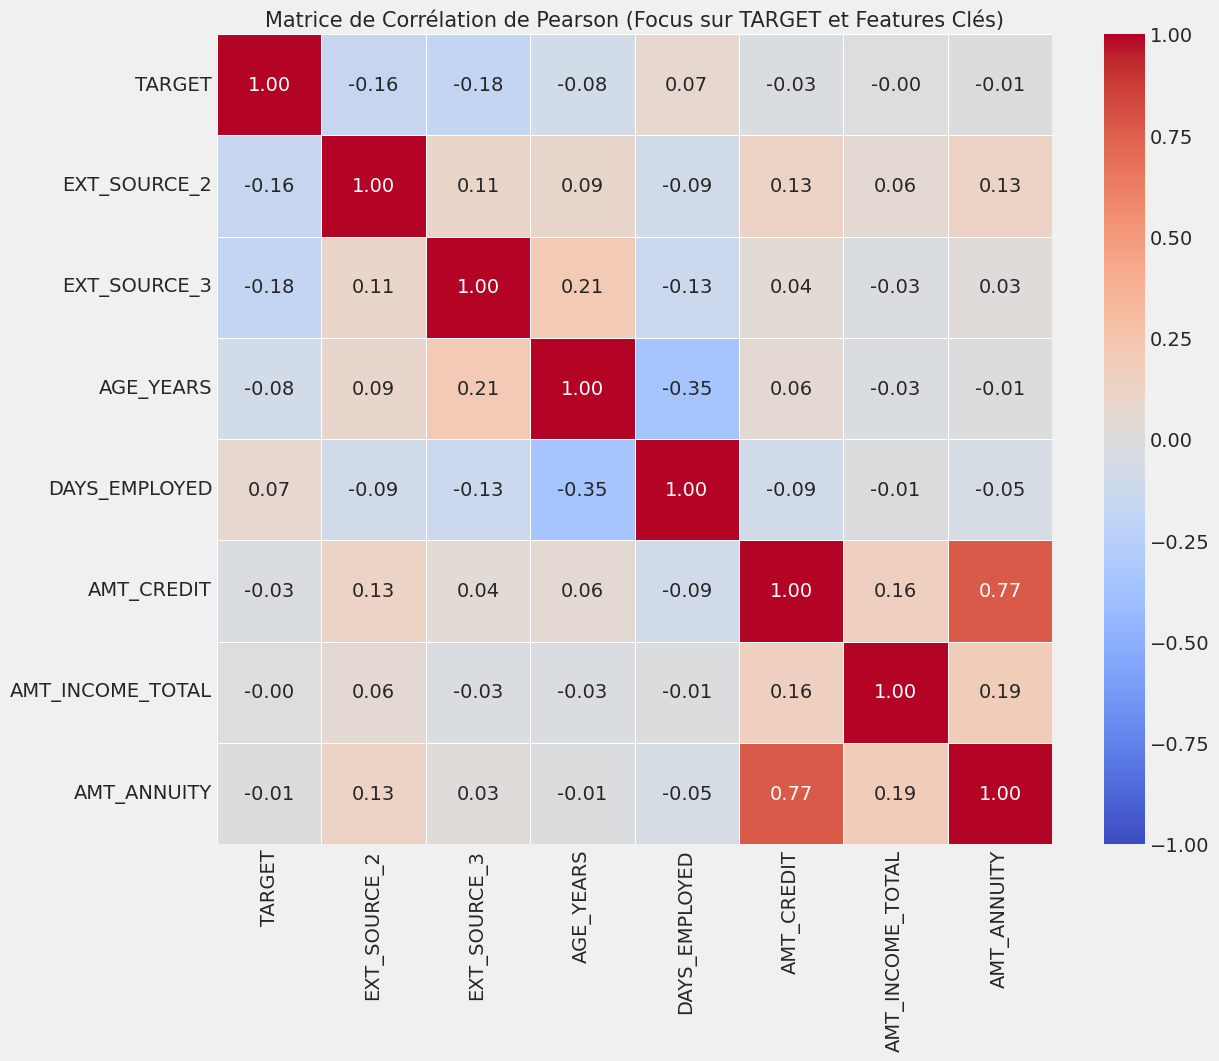

Top des corrélations avec le risque de défaut (TARGET) :
DAYS_EMPLOYED       0.074958
AMT_INCOME_TOTAL   -0.003982
AMT_ANNUITY        -0.012817
AMT_CREDIT         -0.030369
AGE_YEARS          -0.078239
EXT_SOURCE_2       -0.160472
EXT_SOURCE_3       -0.178919
Name: TARGET, dtype: float64


In [ ]:
# Extraction des variables numériques pertinentes + TARGET
numeric_cols = ['TARGET', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
                'AGE_YEARS', 'DAYS_EMPLOYED', 'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY']

# Calcul de la matrice de corrélation de Pearson
corr_matrix = df_train[numeric_cols].corr()

# Visualisation avec une Heatmap Seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title("Matrice de Corrélation de Pearson (Focus sur TARGET et Features Clés)", fontsize=15)
plt.show()

# Affichage du top des corrélations (positives et négatives) avec la TARGET
print("Top des corrélations avec le risque de défaut (TARGET) :")
target_corr = corr_matrix['TARGET'].sort_values(ascending=False)
print(target_corr.drop('TARGET')) # On exclut la TARGET elle-même

## 6. Analyse de la ponctualité : Focus sur `installments_payments.csv`
Cette table contient l'historique exact des paiements. Avant que notre Data Engineer ne l'agrège, nous allons créer deux concepts métiers fondamentaux pour comprendre le comportement des clients :
1. **Les jours de retard (Days Late) :** La différence entre la date de paiement prévue et la date réelle.
2. **Le paiement partiel (Underpayment) :** La différence entre le montant exigé et le montant versé.

Sur cet échantillon, 8.43% des paiements ont été faits en retard.
Sur cet échantillon, 9.52% des paiements étaient incomplets.


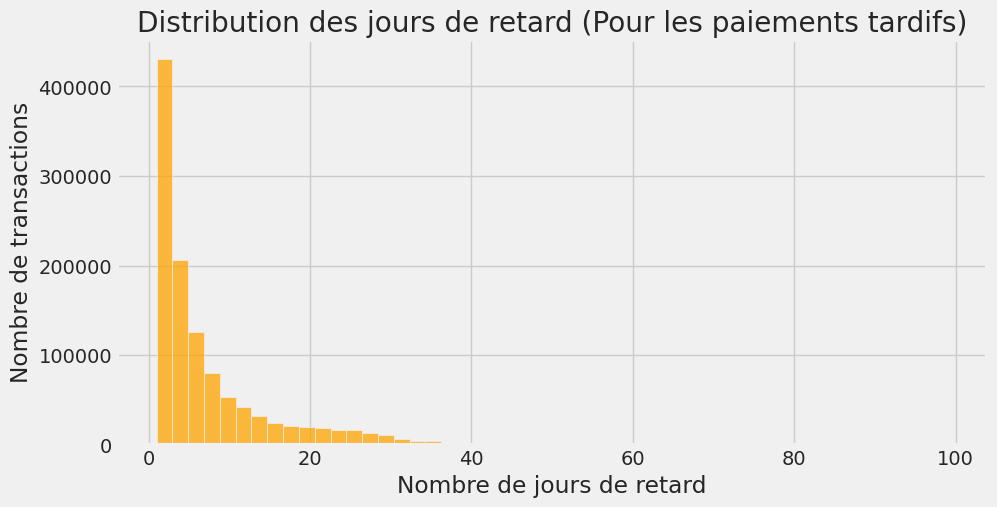

In [ ]:
# 1. Feature Engineering Basique (Création de variables de comportement)
# Jours de retard : Date réelle (ENTRY) - Date prévue (INSTALMENT)
# Si positif = Retard. Si négatif = En avance.
df_install['DAYS_LATE'] = df_install['DAYS_ENTRY_PAYMENT'] - df_install['DAYS_INSTALMENT']

# Paiement partiel : Différence entre le montant payé et le montant attendu
df_install['UNDERPAYMENT'] = df_install['AMT_INSTALMENT'] - df_install['AMT_PAYMENT']

# 2. On isole les paiements "Problématiques"
retards = df_install[df_install['DAYS_LATE'] > 0]
paiements_partiels = df_install[df_install['UNDERPAYMENT'] > 0]

print(f"Sur cet échantillon, {len(retards) / len(df_install) * 100:.2f}% des paiements ont été faits en retard.")
print(f"Sur cet échantillon, {len(paiements_partiels) / len(df_install) * 100:.2f}% des paiements étaient incomplets.")

# 3. Visualisation de la distribution des retards (pour ceux qui sont en retard)
plt.figure(figsize=(10, 5))
# On limite l'affichage à 100 jours de retard max pour lisibilité
sns.histplot(retards[retards['DAYS_LATE'] < 100]['DAYS_LATE'], bins=50, color='orange')
plt.title("Distribution des jours de retard (Pour les paiements tardifs)")
plt.xlabel("Nombre de jours de retard")
plt.ylabel("Nombre de transactions")
plt.show()

**FUSION**

In [ ]:
import polars as pl
import numpy as np
import os

# ============================================================
# 1. CONFIGURATION ET UTILITAIRES
# ============================================================
DATA_PATH = "/content/drive/MyDrive/Data/"

def get_path(file):
    return os.path.join(DATA_PATH, file)

def one_hot_encoder(df):
    """Effectue un One-Hot Encoding sur les colonnes textuelles (Polars)."""
    original_columns = df.columns
    categories = [col for col in original_columns if df[col].dtype == pl.Utf8]

    if not categories:
        return df, []

    df = df.to_dummies(columns=categories)
    new_columns = [c for c in df.columns if c not in original_columns]
    return df, new_columns

def generate_numeric_aggs(agg_dict, prefix):
    """
    Fonction utilitaire qui lit un dictionnaire et génère automatiquement
    les instructions d'agrégation Polars.
    """
    exprs = []
    for col, stats in agg_dict.items():
        for stat in stats:
            # Gestion de la syntaxe spécifique Polars pour "nunique"
            polars_stat = "n_unique" if stat == "nunique" else stat
            exprs.append(getattr(pl.col(col), polars_stat)().alias(f"{prefix}_{col}_{stat.upper()}"))
    return exprs

# ============================================================
# 2. TRAITEMENT DE BUREAU & BUREAU_BALANCE
# ============================================================
def process_bureau():
    bureau = pl.read_csv(get_path("bureau.csv"))
    bb = pl.read_csv(get_path("bureau_balance.csv"))

    # Ensure AMT_ANNUITY is numeric before one-hot encoding
    # Handle potential non-numeric values by coercing errors to null
    if "AMT_ANNUITY" in bureau.columns:
        bureau = bureau.with_columns(pl.col("AMT_ANNUITY").cast(pl.Float64, strict=False))

    # 1. Traitement de Bureau Balance
    bb, bb_cat = one_hot_encoder(bb)
    bb_agg = bb.group_by("SK_ID_BUREAU").agg([
        pl.col("MONTHS_BALANCE").min().alias("BB_MONTHS_MIN"),
        pl.col("MONTHS_BALANCE").max().alias("BB_MONTHS_MAX"),
        pl.col("MONTHS_BALANCE").count().alias("BB_COUNT"),
        *[pl.col(c).mean().alias(f"BB_{c}_MEAN") for c in bb_cat]
    ])

    # 2. Fusion et Traitement de Bureau
    bureau = bureau.join(bb_agg, on="SK_ID_BUREAU", how="left")
    bureau, bureau_cat = one_hot_encoder(bureau)

    # Dictionnaire complet des variables numériques pour Bureau
    num_aggregations = {
        "DAYS_CREDIT": ["min", "max", "mean"],
        "DAYS_CREDIT_ENDDATE": ["min", "max", "mean"],
        "DAYS_ENDDATE_FACT": ["min", "max", "mean"],
        "AMT_CREDIT_MAX_OVERDUE": ["max", "mean"],
        "AMT_CREDIT_SUM": ["min", "max", "mean", "sum"],
        "AMT_CREDIT_SUM_DEBT": ["max", "mean", "sum"],
        "AMT_CREDIT_SUM_LIMIT": ["max", "mean", "sum"],
        "AMT_CREDIT_SUM_OVERDUE": ["max", "mean", "sum"],
        "AMT_ANNUITY": ["max", "mean"],
        "CNT_CREDIT_PROLONG": ["sum"]
    }

    bureau_agg = bureau.group_by("SK_ID_CURR").agg([
        pl.col("SK_ID_BUREAU").count().alias("BURO_COUNT"),
        *[pl.col(c).mean().alias(f"BURO_{c}_MEAN") for c in bureau_cat],
        *generate_numeric_aggs(num_aggregations, "BURO")
    ])
    return bureau_agg

# ============================================================
# 3. TRAITEMENT DE PREVIOUS_APPLICATION
# ============================================================
def process_previous():
    prev = pl.read_csv(get_path("previous_application.csv"))

    # Ensure AMT_ANNUITY is numeric before one-hot encoding
    if "AMT_ANNUITY" in prev.columns:
        prev = prev.with_columns(pl.col("AMT_ANNUITY").cast(pl.Float64, strict=False))

    prev, prev_cat = one_hot_encoder(prev)

    # Remplacement sécurisé des valeurs aberrantes
    prev = prev.with_columns([
        pl.when(pl.col(c) == 365243).then(None).otherwise(pl.col(c)).alias(c)
        for c in ["DAYS_FIRST_DRAWING", "DAYS_FIRST_DUE", "DAYS_LAST_DUE_1ST_VERSION", "DAYS_LAST_DUE", "DAYS_TERMINATION"]
    ])

    # Feature Engineering Métier
    prev = prev.with_columns(
        (pl.col("AMT_APPLICATION") / pl.col("AMT_CREDIT")).alias("APP_CREDIT_PERC")
    )

    num_aggregations = {
        "AMT_ANNUITY": ["max", "mean"],
        "AMT_APPLICATION": ["max", "mean", "sum"],
        "AMT_CREDIT": ["max", "mean", "sum"],
        "APP_CREDIT_PERC": ["max", "mean"],
        "AMT_DOWN_PAYMENT": ["max", "mean"],
        "AMT_GOODS_PRICE": ["max", "mean"],
        "HOUR_APPR_PROCESS_START": ["mean"],
        "RATE_DOWN_PAYMENT": ["mean"],
        "DAYS_DECISION": ["min", "max", "mean"],
        "CNT_PAYMENT": ["max", "mean"]
    }

    prev_agg = prev.group_by("SK_ID_CURR").agg([
        pl.col("SK_ID_PREV").count().alias("PREV_COUNT"),
        *[pl.col(c).mean().alias(f"PREV_{c}_MEAN") for c in prev_cat],
        *generate_numeric_aggs(num_aggregations, "PREV")
    ])
    return prev_agg

# ============================================================
# 4. TRAITEMENT DE POS_CASH_BALANCE
# ============================================================
def process_pos_cash():
    pos = pl.read_csv(get_path("POS_CASH_balance.csv"))
    pos, pos_cat = one_hot_encoder(pos)

    num_aggregations = {
        "MONTHS_BALANCE": ["min", "max", "mean"],
        "CNT_INSTALMENT": ["max", "mean", "sum"],
        "CNT_INSTALMENT_FUTURE": ["max", "mean", "sum"],
        "SK_DPD": ["max", "mean", "sum"],
        "SK_DPD_DEF": ["max", "mean", "sum"]
    }

    pos_agg = pos.group_by("SK_ID_CURR").agg([
        pl.col("SK_ID_PREV").n_unique().alias("POS_COUNT"),
        *[pl.col(c).mean().alias(f"POS_{c}_MEAN") for c in pos_cat],
        *generate_numeric_aggs(num_aggregations, "POS")
    ])
    return pos_agg

# ============================================================
# 5. TRAITEMENT DE INSTALLMENTS_PAYMENTS
# ============================================================
def process_installments():
    ins = pl.read_csv(get_path("installments_payments.csv"))
    ins, ins_cat = one_hot_encoder(ins)

    # Feature Engineering : Retards et Sous-paiements
    ins = ins.with_columns([
        (pl.col("DAYS_ENTRY_PAYMENT") - pl.col("DAYS_INSTALMENT")).alias("DPD"),
        (pl.col("AMT_INSTALMENT") - pl.col("AMT_PAYMENT")).alias("DBD")
    ])

    # On isole les vrais retards (valeurs > 0)
    ins = ins.with_columns([
        pl.when(pl.col("DPD") > 0).then(pl.col("DPD")).otherwise(0).alias("DPD_LATE")
    ])

    num_aggregations = {
        "NUM_INSTALMENT_VERSION": ["nunique"],
        "DAYS_INSTALMENT": ["min", "max", "mean"],
        "DAYS_ENTRY_PAYMENT": ["min", "max", "mean"],
        "AMT_INSTALMENT": ["max", "mean", "sum"],
        "AMT_PAYMENT": ["max", "mean", "sum"],
        "DPD_LATE": ["max", "mean"],
        "DBD": ["max", "mean"]
    }

    ins_agg = ins.group_by("SK_ID_CURR").agg([
        pl.col("SK_ID_PREV").n_unique().alias("INST_COUNT"),
        *[pl.col(c).mean().alias(f"INST_{c}_MEAN") for c in ins_cat],
        *generate_numeric_aggs(num_aggregations, "INST")
    ])
    return ins_agg

# ============================================================
# 6. TRAITEMENT DE CREDIT_CARD_BALANCE
# ============================================================
def process_credit_card():
    cc = pl.read_csv(get_path("credit_card_balance.csv"))
    cc, cc_cat = one_hot_encoder(cc)

    num_aggregations = {
        "MONTHS_BALANCE": ["min", "max", "mean"],
        "AMT_BALANCE": ["max", "mean", "sum"],
        "AMT_CREDIT_LIMIT_ACTUAL": ["max", "mean"],
        "AMT_DRAWINGS_ATM_CURRENT": ["max", "mean", "sum"],
        "AMT_DRAWINGS_CURRENT": ["max", "mean", "sum"],
        "AMT_DRAWINGS_OTHER_CURRENT": ["max", "mean", "sum"],
        "AMT_DRAWINGS_POS_CURRENT": ["max", "mean", "sum"],
        "AMT_INST_MIN_REGULARITY": ["max", "mean"],
        "AMT_PAYMENT_CURRENT": ["max", "mean", "sum"],
        "AMT_PAYMENT_TOTAL_CURRENT": ["max", "mean", "sum"],
        "AMT_RECEIVABLE_PRINCIPAL": ["max", "mean"],
        "AMT_RECIVABLE": ["max", "mean"],
        "AMT_TOTAL_RECEIVABLE": ["max", "mean"],
        "CNT_DRAWINGS_ATM_CURRENT": ["mean", "sum"],
        "CNT_DRAWINGS_CURRENT": ["mean", "sum"],
        "CNT_DRAWINGS_OTHER_CURRENT": ["mean", "sum"],
        "CNT_DRAWINGS_POS_CURRENT": ["mean", "sum"],
        "CNT_INSTALMENT_MATURE_CUM": ["max", "mean"],
        "SK_DPD": ["max", "mean", "sum"],
        "SK_DPD_DEF": ["max", "mean", "sum"]
    }

    cc_agg = cc.group_by("SK_ID_CURR").agg([
        pl.col("SK_ID_PREV").n_unique().alias("CC_COUNT"),
        *[pl.col(c).mean().alias(f"CC_{c}_MEAN") for c in cc_cat],
        *generate_numeric_aggs(num_aggregations, "CC")
    ])
    return cc_agg

# ============================================================
# 7. FUSION FINALE (MAIN)
# ============================================================
def main_merging():
    print("Démarrage du pipeline de Data Engineering...")

    # 1. Table principale
    df = pl.read_csv(get_path("application_train.csv"))

    # 2. Nettoyage et Feature Engineering sur Train
    df = df.with_columns([
        pl.when(pl.col("DAYS_EMPLOYED") == 365243).then(None).otherwise(pl.col("DAYS_EMPLOYED")).alias("DAYS_EMPLOYED"),
        (pl.col("DAYS_BIRTH") / -365).alias("AGE_YEARS"),
        (pl.col("AMT_ANNUITY") / pl.col("AMT_INCOME_TOTAL")).alias("ANNUITY_INCOME_PERC"),
        (pl.col("AMT_CREDIT") / pl.col("AMT_INCOME_TOTAL")).alias("CREDIT_INCOME_PERC")
    ])

    # 3. Jointures successives (Left Join)
    print("Traitement et fusion de Bureau...")
    df = df.join(process_bureau(), on="SK_ID_CURR", how="left")

    print("Traitement et fusion de Previous Applications...")
    df = df.join(process_previous(), on="SK_ID_CURR", how="left")

    print("Traitement et fusion de POS CASH...")
    df = df.join(process_pos_cash(), on="SK_ID_CURR", how="left")

    print("Traitement et fusion de Installments Payments...")
    df = df.join(process_installments(), on="SK_ID_CURR", how="left")

    print("Traitement et fusion de Credit Card Balance...")
    df = df.join(process_credit_card(), on="SK_ID_CURR", how="left")

    # 4. Sauvegarde finale
    output_path = get_path("train_final_merged.csv")
    print(f"Écriture du fichier final vers : {output_path}...")
    df.write_csv(output_path)
    print(f"Fusion terminée avec succès ! Dimensions finales : {df.shape}")

if __name__ == "__main__":
    main_merging()

Démarrage du pipeline de Data Engineering...
Traitement et fusion de Bureau...
Traitement et fusion de Previous Applications...
Traitement et fusion de POS CASH...
Traitement et fusion de Installments Payments...
Traitement et fusion de Credit Card Balance...
Écriture du fichier final vers : /content/drive/MyDrive/Data/train_final_merged.csv...
Fusion terminée avec succès ! Dimensions finales : (307511, 444)


Chargement de la base fusionnée...
Dimensions de X : 307511 lignes, 442 variables.

Lancement de la validation croisée (cela peut prendre quelques minutes)...
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 3.088511 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 57446
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 438
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.682275 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 57545
[LightGBM] [Info] Number of data points in the train set: 246009, number o

/tmp/ipykernel_69042/2364976815.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp.head(20), palette='viridis')


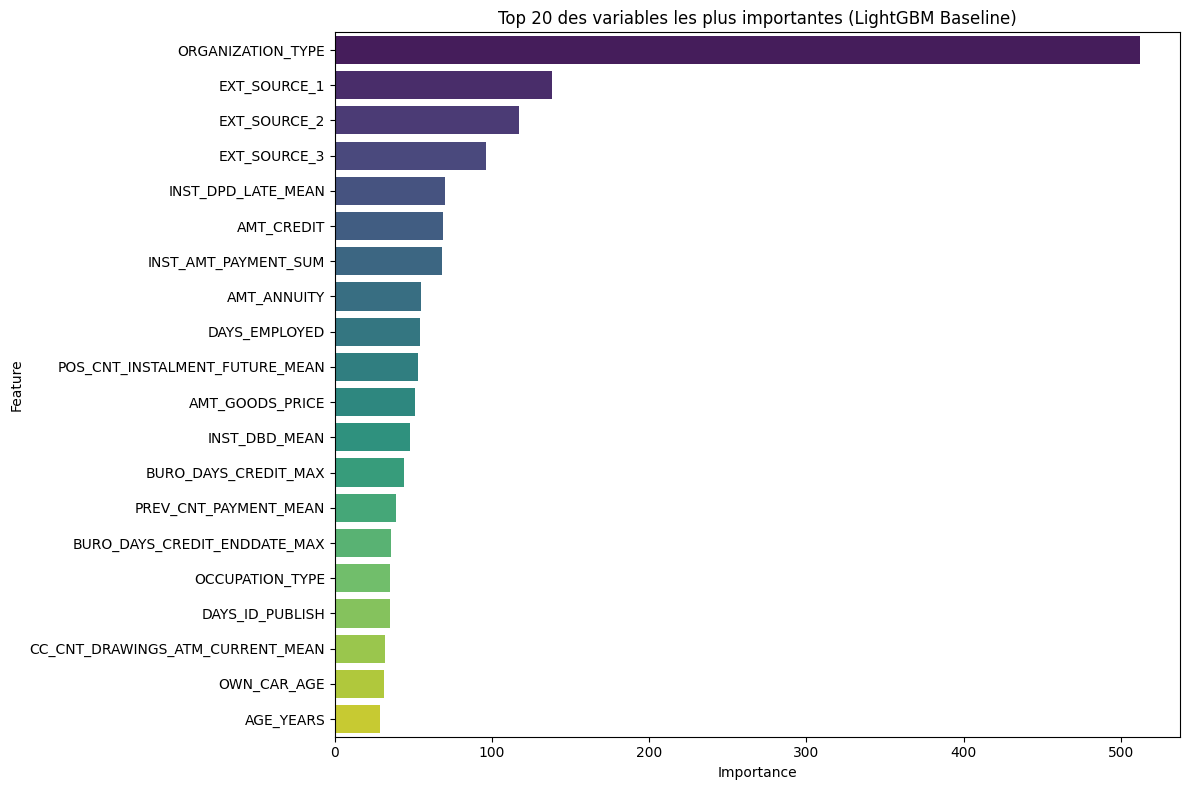

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import re

# ============================================================
# 1. CHARGEMENT ET PRÉPARATION
# ============================================================
print("Chargement de la base fusionnée...")
# On utilise pandas ici car LightGBM s'interface parfaitement avec les DataFrame pandas
df = pd.read_csv("/content/drive/MyDrive/Data/train_final_merged.csv")

# ASTUCE PRO : Nettoyage des noms de colonnes
# LightGBM déteste les espaces ou caractères spéciaux (comme ':') dans les noms de colonnes
# qui ont pu être générés lors du One-Hot Encoding de Polars.
df = df.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))

# Séparation des features (X) et de la cible (y)
X = df.drop(columns=['SK_ID_CURR', 'TARGET'])
y = df['TARGET']

# Correction de l'erreur LightGBM: Conversion des colonnes 'object' en 'category'
# LightGBM peut gérer les features catégorielles si elles sont de type 'category'.
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].astype('category')

print(f"Dimensions de X : {X.shape[0]} lignes, {X.shape[1]} variables.")

# ============================================================
# 2. CONFIGURATION DU MODÈLE BASELINE
# ============================================================
# class_weight='balanced' force le modèle à pénaliser plus fortement les erreurs sur la classe 1
lgb_clf = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1 # Utilise tous les cœurs du processeur
)

# Configuration de la validation croisée (Stratified pour respecter le déséquilibre)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ============================================================
# 3. ÉVALUATION (CROSS-VALIDATION)
# ============================================================
print("\nLancement de la validation croisée (cela peut prendre quelques minutes)...")
cv_scores = cross_val_score(lgb_clf, X, y, cv=cv, scoring='roc_auc')

print(f"Scores AUC-ROC par fold : {cv_scores}")
print(f"--> AUC-ROC Moyen : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# ============================================================
# 4. EXPLORATION : FEATURE IMPORTANCE
# ============================================================
# Pour voir quelles variables de la base fusionnée sont les plus utiles,
# nous entraînons le modèle une fois sur toutes les données.
print("\nEntraînement final pour l'extraction de l'importance des variables...")
lgb_clf.fit(X, y)

# Création d'un DataFrame pour la Feature Importance
feature_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lgb_clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Affichage du Top 20
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp.head(20), palette='viridis')
plt.title('Top 20 des variables les plus importantes (LightGBM Baseline)')
plt.tight_layout()
plt.show()